# Spatial Combinational Complexes for Hyperlocal Air Quality Downscaling

This notebook presents the required steps to reproduce the geospatial combinational complex benchmark dataset used in the $E(n)$-equivariant topological neural networks.

Unfortunatelly, some of the steps require downloading large files manually, which are subject to changes in the API of their corresponding sources. We include the steps here which are functional as of June 14, 2024.

## 1. Prerequisites

### Dependencies

In [3]:
# tested on python 3.10
%pip install -q \
    geopandas \
    matplotlib \
    pygris \
    tqdm \
    osmnx \
    contextily \
    ipykernel \
    IProgress \
    pyarrow \
    scikit-learn    


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load libraries

In [2]:
import geopandas as gpd
import pandas as pd
import pygris
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import matplotlib
from tqdm.notebook import tqdm
import osmnx as ox
import contextily as cx
import json
from sklearn.neighbors import NearestNeighbors
import os

plt.rcParams["figure.figsize"] = [8, 8]
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
# Supress warnings
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

root_dir ="/Users/jdella/topological-equivariant-networks"

### Manual Downloads

There are two data sources that require manual downloading. These sources are the AADT (Annual Average Daily Traffic) from the NY State Department of Transportation and the PLUTO (Primary Land Use Tax Lot Output) dataset from the NYC Department of City Planning.

#### Annual Average Daily Traffic (AADT)

Go the NY State DOT website with the AADT data:
[https://nysdottrafficdata.drakewell.com/publicmultinodemap.asp](https://nysdottrafficdata.drakewell.com/publicmultinodemap.asp)

Under the right navigation menu, panel `Annual Statistics`, select the option `All Station AADT and Truck Percent`, and download as `Shapefile`. After downloading the file, it must be uncompress in the `data` directory. This is how the uncompress file should look like:

```folder
data/input/
  aadt_and_truckpct/
    features.shp
    features.shx
    features.dbf
    features.prj
  ...
```

#### Primary Land Use Tax Lot Output (PLUTO)

Go to the NYC Department of City Planning website with the PLUTO data at:
[https://www.nyc.gov/site/planning/data-maps/open-data/dwn-pluto-mappluto.page]

Select the file `PLUTO (.csv format)` and download it to the `data` directory.

```folder
data/input/
  nyc_pluto_24v1_1_csv/
    pluto_24v1_1
    pluto_readme.pdf
    pluto_datadictionary.pdf
  ...
```

## 2. Geometry Processing

#### Automatic PM 2.5 data download from MIT-Seansable City

In [6]:
urls = [
    f"https://raw.githubusercontent.com/MIT-Senseable-City-Lab/OSCS/main/Explore/Datasets/NYC_Pilot2_PM_Part{i}.csv"
    for i in [1, 2, 3]
]

info = {
    "target": "pm25",
    "lat": "latitude",
    "lon": "longitude",
    "time": "time",
    "time_input_format": "unix",
    "time_zone": "US/Eastern",
    "features": ["temperature", "humidity"],
    "ids": ["SensorID"],
}

# download the three datasets
pts = []
for url in urls:
    chunk = pd.read_csv(url)
    pts.append(chunk)
pts = pd.concat(pts, ignore_index=True)

# convert the time column to local time
pts["time"] = pd.to_datetime(pts[info["time"]], unit="s")
pts["time"] = pts["time"].dt.tz_localize("UTC").dt.tz_convert(info["time_zone"])

# filter columns
cols = (
    info["ids"]
    + [info["time"], info["lon"], info["lat"], info["target"]]
    + info["features"]
)
pts = pts[cols]

# rename lon/lat columns
pts = pts.rename(columns={info["lon"]: "lon", info["lat"]: "lat"})
pts["time_of_day"] = pts.time.dt.hour + pts.time.dt.minute / 60
pts["weekday"] = pts.time.dt.weekday

# keep measurements during weekdays and 9am to 5pm
pts = pts[(pts.weekday < 5) & (pts.time_of_day >= 9) & (pts.time_of_day <= 17)]

# print date range
print(pts.time.min(), pts.time.max())

# original shape
print(pts.shape)

2021-09-10 09:00:00-04:00 2021-12-15 09:35:55-05:00
(242282, 9)


Coarsen points / keep polygons that contain points

In [7]:
# 1) Define the grid resolution for spatial rounding.
#    delta_s is in degrees; here 0.0002° ≈ 20 meters on the ground.
delta_s = 0.0002  # grid cell size

# 2) “Snap” each longitude to the nearest grid cell center:
#    - pts.lon / delta_s  → how many grid‐cells wide each lon is
#    - np.round(...)      → nearest integer cell index
#    - * delta_s          → back to a longitude value
pts["lon"] = delta_s * np.round(pts.lon / delta_s)

# 3) Do the same snapping for latitude.
pts["lat"] = delta_s * np.round(pts.lat / delta_s)

# 4) Decide which columns define a unique spatial bin:
group_cols = ["lon", "lat"]

# 5) Group the DataFrame by those binned lon/lat coordinates.
#    Within each bin we’ll reduce multiple measurements down to a single
#    representative value via the median.
pts = (
    pts
    .groupby(group_cols)
    .agg(
        # For the air‐quality reading, keep the median pm2.5 value
        pm25=pd.NamedAgg(column="pm25", aggfunc=np.median),
        # For time_of_day, also take the median (so you ignore the date entirely)
        time_of_day=pd.NamedAgg(column="time_of_day", aggfunc=np.median),
    )
    .reset_index()  # turn lon/lat back into regular columns instead of index
)

# 6) Check how many binned points you end up with.
print(f"Shape after grouping: {pts.shape}")

Shape after grouping: (12741, 4)


#### Get geometries for the  combinatiorial complex objects.

Each rank corresponds to a type of geospatial (GIS) object:

1. **(Rank 0)**: Points
2. **(Rank 1)**: Polylines
3. **(Rank 2)**: Polygons

In [8]:
# 1) Define CRS strings for later reprojections:
#    - WGS84 (EPSG:4326) uses degrees (latitude/longitude).
#    - Web Mercator (EPSG:3857) uses meters (good for distance computations).
wgs84 = "EPSG:4326"    # geographic CRS, units = degrees
mercator = "EPSG:3857" # projected CRS, units = meters

# ==== RANK 0: POINTS ====
# 2) Create Shapely Point geometries from our lon/lat columns,
#    telling GeoPandas they’re in WGS84.
geom = gpd.points_from_xy(pts.lon, pts.lat, crs=wgs84)

# 3) Build a GeoDataFrame from the existing 'pts' DataFrame,
#    adding a 'geometry' column so spatial ops will work.
pts = gpd.GeoDataFrame(pts, geometry=geom)

# ==== RANK 1: ROADS =====
# 4) Download the road network for Bronx County, NY via pygris.
# 5) Immediately reproject those road geometries back to WGS84
#    so they align with our points.
roads = (
    pygris.roads(state="NY", county="Bronx")
    .to_crs(wgs84)
)

# ==== RANK 2: TRACTS ====
# 6) Fetch the Census tracts for Bronx County (year 2020), using
#    the cartographic boundary files (cb=True) and caching for speed.
# 7) Reproject tracts to WGS84 so they line up with points & roads.
tracts = (
    pygris.tracts(
        state="NY",
        county="Bronx",
        year=2020,
        cache=True,
        cb=True
    )
    .to_crs(wgs84)
)

# 8) Convert the tract identifier (TRACTCE) from string to integer
#    for easier numeric indexing.
tracts["TRACTCE"] = tracts["TRACTCE"].astype(int)

# 9) Set the tract code as the GeoDataFrame’s index, so you can
#    look up a tract by its ID directly.
tracts.set_index("TRACTCE", inplace=True)

Using the default year of 2024
Using FIPS code '36' for input 'NY'
Using FIPS code '005' for input 'Bronx'
Using FIPS code '36' for input 'NY'
Using FIPS code '005' for input 'Bronx'


Keep only valid points/roads/tracts that interesect (ensures valid combinatorial complex).

In [20]:
# add a 5m buffer around roads to obtain intersections with other geometries
geom = roads.geometry.to_crs(mercator).buffer(5).to_crs(wgs84)
road_buff = gpd.GeoDataFrame(geometry=geom)
sjoin1 = gpd.sjoin(pts, road_buff, predicate="within", how="inner")
valid_pts1 = sjoin1.index.unique()

# similarly, add a 5m buffer around tracts
geom = tracts.geometry.to_crs(mercator).buffer(5).to_crs(wgs84)
tract_buff = gpd.GeoDataFrame(geometry=geom)
sjoin2 = gpd.sjoin(pts, tract_buff, predicate="within", how="inner")
valid_pts2 = sjoin2.index.unique()

# keep only points that are valid in both cases
valid_pts = list(set(valid_pts1) & set(valid_pts2))

# take subset of valid points, roads, and tracts
pts = pts.loc[valid_pts]
sjoin1 = sjoin1.loc[sjoin1.index.isin(valid_pts)]
sjoin2 = sjoin2.loc[sjoin2.index.isin(valid_pts)]
valid_roads = sjoin1.index_right.unique()
valid_tracts = sjoin2["TRACTCE"].unique()
sjoin1 = sjoin1.loc[sjoin1.index_right.isin(valid_roads)]
sjoin2 = sjoin2.loc[sjoin2["TRACTCE"].isin(valid_tracts)]
roads = roads.loc[valid_roads]
roads_buff = road_buff.loc[valid_roads]
tracts = tracts.loc[valid_tracts]
tract_buff = tract_buff.loc[valid_tracts]

# obtain a map from index to ordering
ixmap_pts = {k: i for i, k in enumerate(pts.index)}
ixmap_roads = {k: i for i, k in enumerate(roads.index)}
ixmap_tracts = {k: i for i, k in enumerate(tracts.index)}

print("Final set of points")
display(pts)

print("Final set of roads")
display(roads)

print("Final set of tracts")
display(tracts)

Final set of points


,lon,lat,pm25,time_of_day,geometry
8199,-73.8882,40.8266,3.288390,11.183333,POINT (-73.8882 40.8266)
8201,-73.8882,40.8288,4.348238,13.200000,POINT (-73.8882 40.8288)
8207,-73.8882,40.8330,10.109027,14.033333,POINT (-73.8882 40.833)
8214,-73.8882,40.8366,4.366279,14.966667,POINT (-73.8882 40.8366)
8218,-73.8882,40.8398,3.763369,14.766667,POINT (-73.8882 40.8398)
...,...,...,...,...,...
8183,-73.8882,40.8178,3.087006,9.716667,POINT (-73.8882 40.8178)
8186,-73.8882,40.8204,5.729451,12.183333,POINT (-73.8882 40.8204)
8187,-73.8882,40.8206,5.471461,10.750000,POINT (-73.8882 40.8206)
8189,-73.8882,40.8214,10.635258,15.650000,POINT (-73.8882 40.8214)


Final set of roads


,LINEARID,FULLNAME,RTTYP,MTFCC,geometry
1927,1106087327893,Westchester Ave,M,S1400,"LINESTRING (-73.91676 40.81656, -73.91572 40.8..."
498,110391524724,W Farms Rd,M,S1400,"LINESTRING (-73.89139 40.82494, -73.89145 40.8..."
1587,110391523820,Home St,M,S1400,"LINESTRING (-73.90346 40.82853, -73.90283 40.8..."
1931,110391524002,Vyse Ave,M,S1400,"LINESTRING (-73.88998 40.82681, -73.88994 40.8..."
1255,110391528710,Southern Blvd,M,S1400,"LINESTRING (-73.90844 40.80648, -73.90821 40.8..."
...,...,...,...,...,...
2305,110391524719,Faile St,M,S1400,"LINESTRING (-73.8893 40.82143, -73.88948 40.82..."
2662,110391525600,Irvine St,M,S1400,"LINESTRING (-73.88853 40.81871, -73.88888 40.82)"
0,1104691956808,Bryant Ave Ovp,M,S1710,"LINESTRING (-73.88891 40.82181, -73.88858 40.8..."
904,110391526450,Gilbert Pl,M,S1400,"LINESTRING (-73.88866 40.81776, -73.88739 40.8..."


Final set of tracts


,STATEFP,COUNTYFP,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
TRACTCE,,,,,,,,,,,,,
12701,36,005,1400000US36005012701,36005012701,127.01,Census Tract 127.01,NY,Bronx County,New York,CT,108718,0,"POLYGON ((-73.89484 40.82624, -73.89387 40.826..."
12102,36,005,1400000US36005012102,36005012102,121.02,Census Tract 121.02,NY,Bronx County,New York,CT,49643,0,"POLYGON ((-73.89066 40.82531, -73.88881 40.826..."
12101,36,005,1400000US36005012101,36005012101,121.01,Census Tract 121.01,NY,Bronx County,New York,CT,115615,0,"POLYGON ((-73.89088 40.82863, -73.89087 40.830..."
15700,36,005,1400000US36005015700,36005015700,157,Census Tract 157,NY,Bronx County,New York,CT,319009,0,"POLYGON ((-73.89071 40.83241, -73.88973 40.834..."
15500,36,005,1400000US36005015500,36005015500,155,Census Tract 155,NY,Bronx County,New York,CT,114981,0,"POLYGON ((-73.89216 40.83364, -73.89082 40.835..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12500,36,005,1400000US36005012500,36005012500,125,Census Tract 125,NY,Bronx County,New York,CT,169640,0,"POLYGON ((-73.8967 40.83041, -73.89469 40.8306..."
15900,36,005,1400000US36005015900,36005015900,159,Census Tract 159,NY,Bronx County,New York,CT,103601,0,"POLYGON ((-73.89586 40.82263, -73.8939 40.8236..."
36902,36,005,1400000US36005036902,36005036902,369.02,Census Tract 369.02,NY,Bronx County,New York,CT,62406,0,"POLYGON ((-73.89481 40.84376, -73.89291 40.843..."


### Cell membership indicators

Recall that from the point of view of combinatorial complexes (CCs), a cell is described entirely by the atoms it contains. Thus we much specify the rank 1 cells (roads) and the rank 2 cells (tracts) by which points they contain.

In [37]:
# rank 0 cells are trivial singletons
cell_0 = [[i] for i in range(len(pts))]

# leverage that sjoin1 and sjoin2 already contain the necessary information
# of which points are in which road/tract
cell_1 = [[] for _ in range(len(roads))]
cell_2 = [[] for _ in range(len(tracts))]

for ix, row in sjoin1.iterrows():
    src = ixmap_pts[ix]
    dst = ixmap_roads[row["index_right"]]
    cell_1[dst].append(src)

for ix, row in sjoin2.iterrows():
    src = ixmap_pts[ix]
    dst = ixmap_tracts[row["TRACTCE"]]
    cell_2[dst].append(src)

As an extra computation that will be useful later, obtain the inverse mapping. That is, for each point, to which roads/tracts it belongs. In almost all cases a point only belong to onre road and one tract (exceptions only at the edges, and mostly due to the buffer).

In [38]:
map_0_1 = [[] for _ in range(len(pts))]
map_0_2 = [[] for _ in range(len(pts))]

for ix, row in sjoin1.iterrows():
    src = ixmap_pts[ix]
    dst = ixmap_roads[row["index_right"]]
    map_0_1[src].append(dst)

for ix, row in sjoin2.iterrows():
    src = ixmap_pts[ix]
    dst = ixmap_tracts[row["TRACTCE"]]
    map_0_2[src].append(dst)

pts["road"] = map_0_1
pts["tract"] = map_0_2

### Create indicidences (upper/lower adjacencies) by the common neighbors rule

In [39]:
# === Incidences Rank 0 -> Rank 1 (used also as incidence(0, 1)) ====
edges_pts_road = set()
for i in range(len(pts)):
    for j, c in enumerate(cell_1):
        if i in c:
            edges_pts_road.add((i, j))
edges_pts_road = list(edges_pts_road)
print("Number of edges pts -> road", len(edges_pts_road))

# === Incidences Rank 1 -> Rank 2 ====
# strategy: create neighbors if they road and tract share a point
edges_road_tract = set()
for i, road in enumerate(cell_1):
    for k, tract in enumerate(cell_2):
        if set(road) & set(tract):
            edges_road_tract.add((i, k))
edges_road_tract = list(edges_road_tract)
print("Number of edges road -> tract", len(edges_road_tract))

Number of edges pts -> road 4938
Number of edges road -> tract 1332


### Visualize the resulting adjacencies

/var/folders/kp/dyyv0jvn7lx3wgs3md0sk2mc0000gn/T/ipykernel_72845/1180306514.py:26: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  tract_feats_k.plot(
/var/folders/kp/dyyv0jvn7lx3wgs3md0sk2mc0000gn/T/ipykernel_72845/1180306514.py:34: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  tract_feats_k.plot(


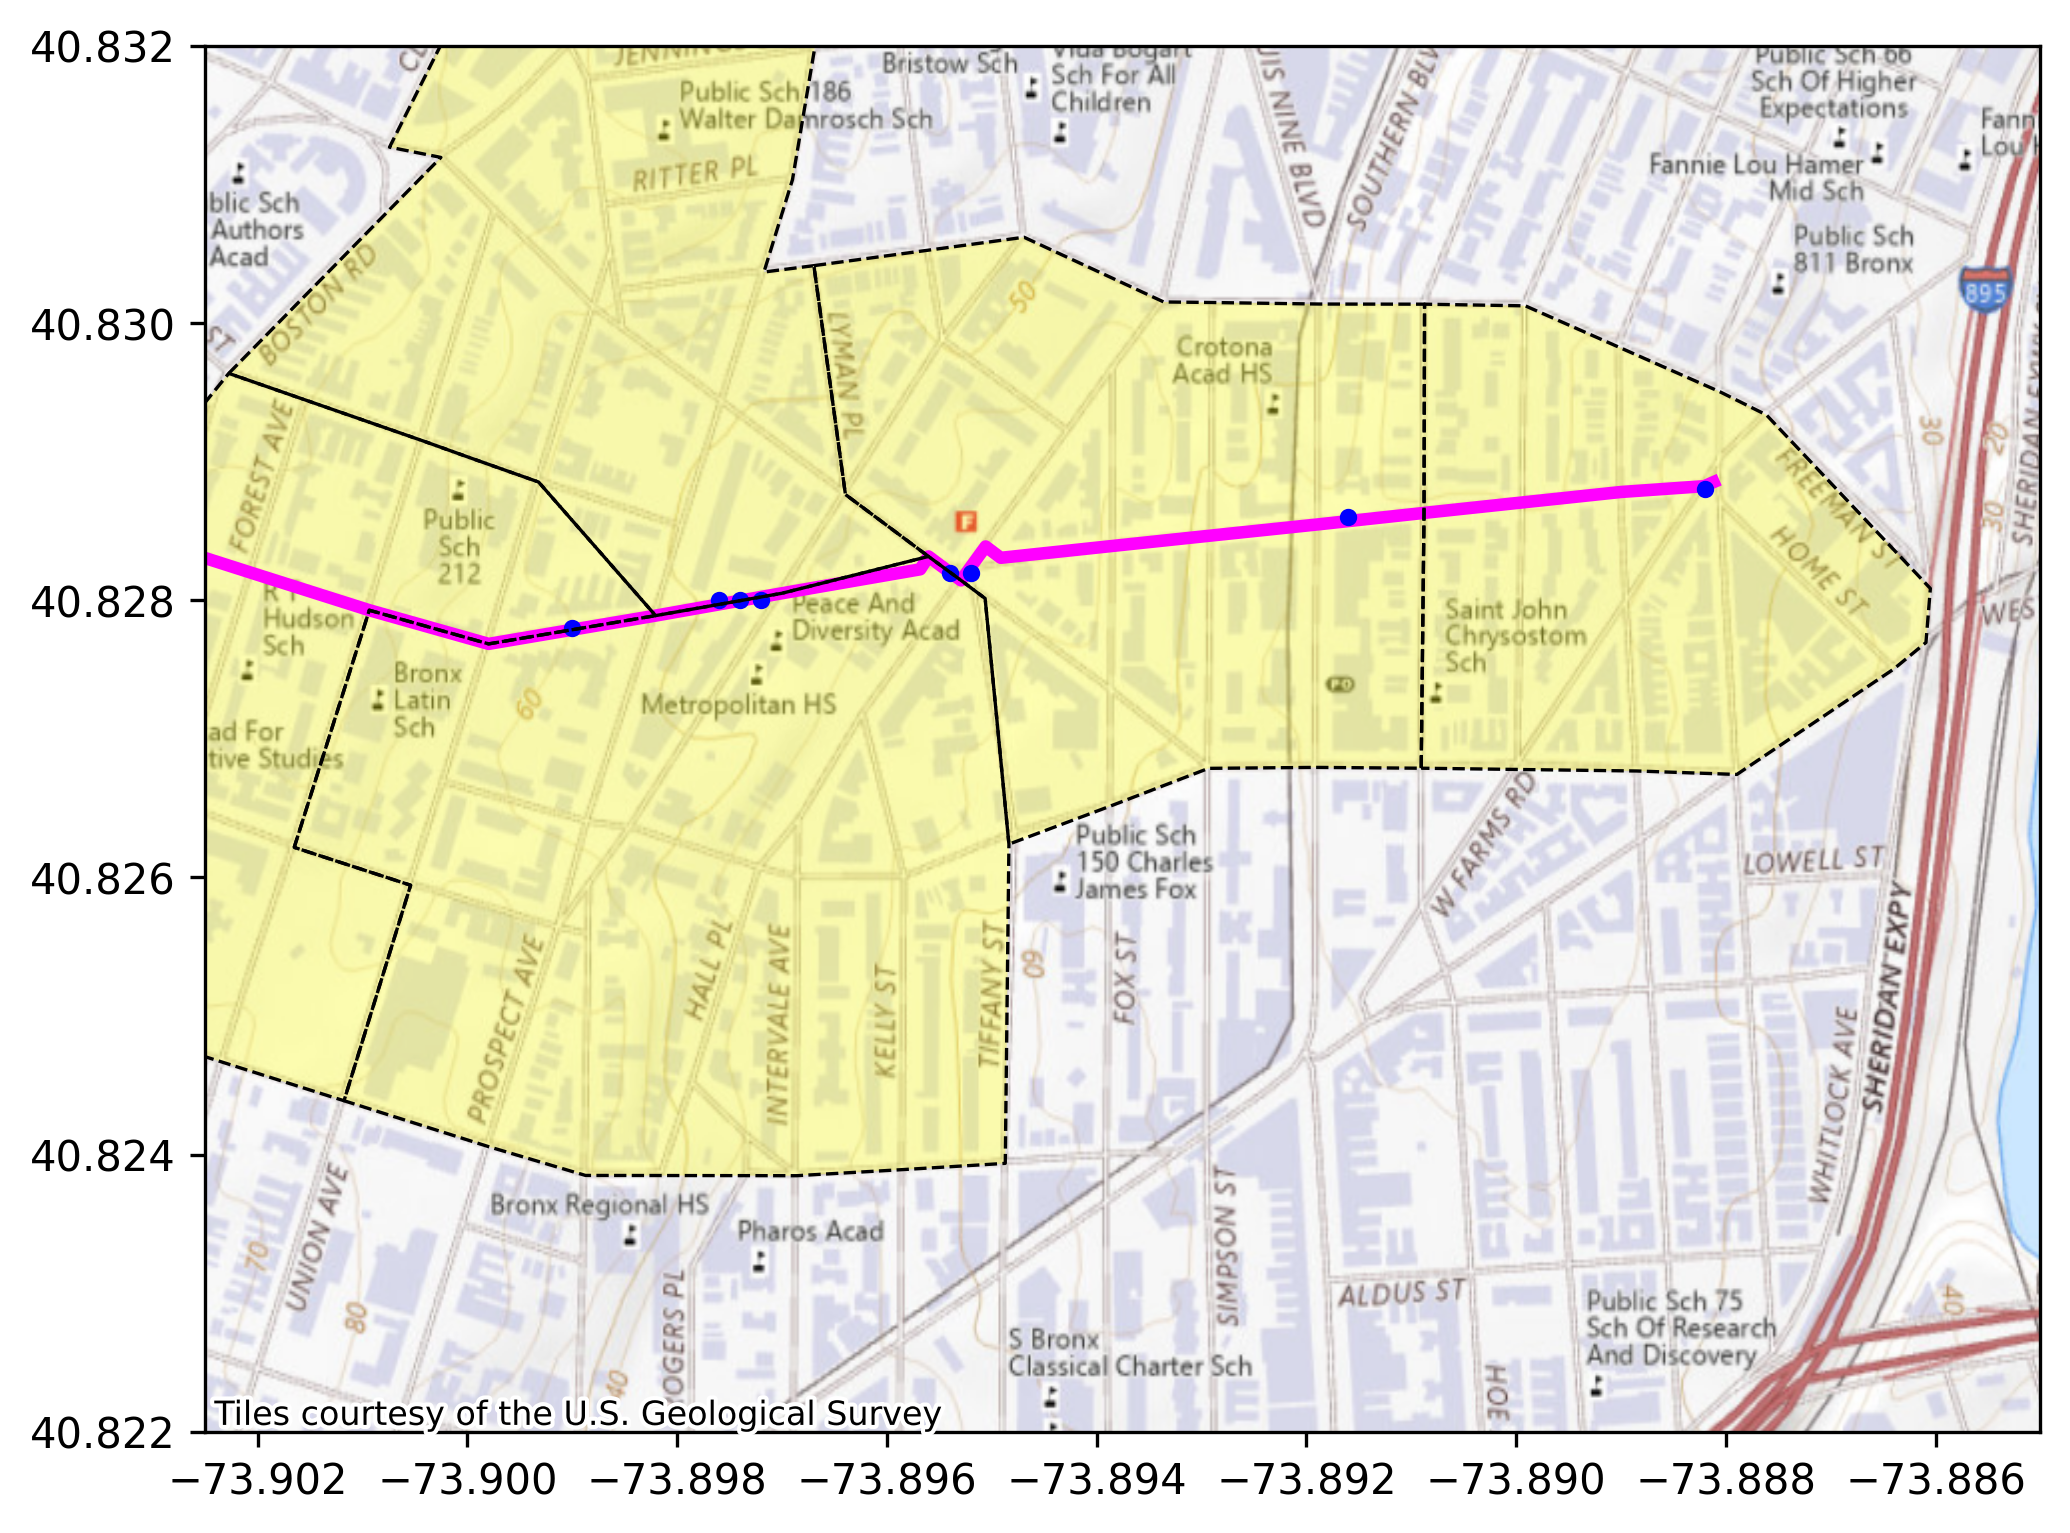

<Axes: >

In [52]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# iterate until we find the road that is closest the tgt point
tgt_point = np.array([40.828, -73.896])
closest_road = None
closest_dist = np.inf
for i, (index, row) in enumerate(roads.iterrows()):
    dist = row.geometry.distance(gpd.points_from_xy([tgt_point[1]], [tgt_point[0]])[0])
    if dist < closest_dist:
        closest_dist = dist
        closest_road = i

# Obtain the points, roads, and tracts to be displayed in the Figure, and their features
tgt_pts = [e[0] for e in edges_pts_road if e[1] == closest_road]
pts_k = pts.iloc[tgt_pts]

tgt_roads = [closest_road]
road_feats_k = roads.iloc[tgt_roads]

tgt_tracts = [e[1] for e in edges_road_tract if e[0] == closest_road]
tract_feats_k = tracts.iloc[tgt_tracts]


# roads.plot(ax=ax, color="black", alpha=0.1)
# make fill collor always yello
tract_feats_k.plot(
    "id",
    alpha=0.3,
    lw=0.0,
    ls="--",
    color="yellow",
    ax=ax,
)
tract_feats_k.plot(
    "id",
    edgecolor="black",
    ls="--",
    alpha=1.0,
    lw=0.8,
    color="none",
    ax=ax,
    zorder=11
)
road_feats_k.plot(color="magenta", linewidth=3, ax=ax)
# ensure pts appear on top of other plots
pts_k.plot(markersize=10, ax=ax, c="blue", zorder=10)

# plt.title("Example of road intersecting tracts")

# make sure that the axis coordinates do not use scientific notation
ax.get_xaxis().get_major_formatter().set_useOffset(False)
ax.get_yaxis().get_major_formatter().set_useOffset(False)
plt.xlim(-73.9025, -73.885)
plt.ylim(40.822, 40.832)
cx.add_basemap(ax, crs=tracts.crs, zoom=16, source=cx.providers.USGS.USTopo)
plt.show()

# save as png
fig.savefig(f"{root_dir}/notebooks/figs/spatial-cc-example.png", bbox_inches="tight")
ax

## 3. Feature Engineering

### Points (rank 0)

The points contain the labels (PM 2.5 at high resolution) and are complemented with predictions from open street map such as restaurants, schools, and traffic intersections with a radius.

In [48]:
# === Fetch OpenStreetMap data ===

# Step 1: Define your area of interest
place_name = "Bronx, New York, USA"

# Step 2: Download list of restaurants and schools
tags = {"amenity": ["restaurant", "school"]}
amenities = ox.features_from_place(place_name, tags)
ox_net = ox.graph_from_place(place_name, network_type="all")
# Convert the graph to a GeoDataFrame
ox_net_nodes, ox_net_edges = ox.graph_to_gdfs(ox_net)

ox_net_edges = ox_net_edges.to_crs(mercator)
ox_net_nodes = ox_net_nodes.to_crs(mercator)

# Step 3: Separate restaurants and schools into different GeoDataFrames
restaurants = amenities[amenities["amenity"] == "restaurant"].loc['node']
schools = amenities[amenities["amenity"] == "school"].loc['node']

In [49]:
## === Featurize by computing densities ===

# Make bufferes point data
buffer_distance1 = 300  # Buffer distance in meters
buffer_distance2 = 100  # Buffer distance in meters
buffered_pts_geom1 = pts.to_crs(mercator).buffer(buffer_distance1)
buffered_pts_geom2 = pts.to_crs(mercator).buffer(buffer_distance2)
buffered_pts = pts.to_crs(mercator).copy()
buffered_pts["buffer1"] = buffered_pts_geom1
buffered_pts["buffer2"] = buffered_pts_geom2

# Reproject to a projected coordinate system for accurate area calculations
restaurants = restaurants.to_crs(mercator)
schools = schools.to_crs(mercator)

C1 = buffer_distance1**2 * np.pi
C2 = buffer_distance2**2 * np.pi

# Calculate the proximity to the nearest school
def calculate_nearest_school_distance(point):
    distances = schools.geometry.distance(point) / 1e3  # in kilometers
    return distances.min()

# Function to calculate road and intersection density within a buffer
def calculate_densities(buffer, edges=ox_net_edges, nodes=ox_net_nodes):
    # Clip edges and nodes to the buffer
    clipped_edges = edges[edges.intersects(buffer)]
    clipped_nodes = nodes[nodes.intersects(buffer)]

    # Calculate road length and area
    road_length_km = clipped_edges["length"].sum() / 1e3  # in kilometers

    # Calculate intersection count
    intersection_count = len(clipped_nodes)

    # Calculate densities
    road_density = road_length_km / C2
    intersection_density = intersection_count / C2

    return road_density, intersection_density

restaurant_density = []
school_distance = []
road_density = []
intersection_density = []
for ix, row in tqdm(buffered_pts.iterrows(), total=len(buffered_pts)):
    restaurant_density.append(1000 * restaurants.intersects(row.buffer1).sum() / C1)
    school_distance.append(calculate_nearest_school_distance(row.geometry))
    rd, id = calculate_densities(row.buffer2)
    road_density.append(rd)
    intersection_density.append(id)

pts["restaurant_density"] = restaurant_density
pts["nearest_school_distance"] = school_distance
pts["road_density"] = road_density
pts["intersection_density"] = intersection_density

  0%|          | 0/3939 [00:00<?, ?it/s]

Visualize

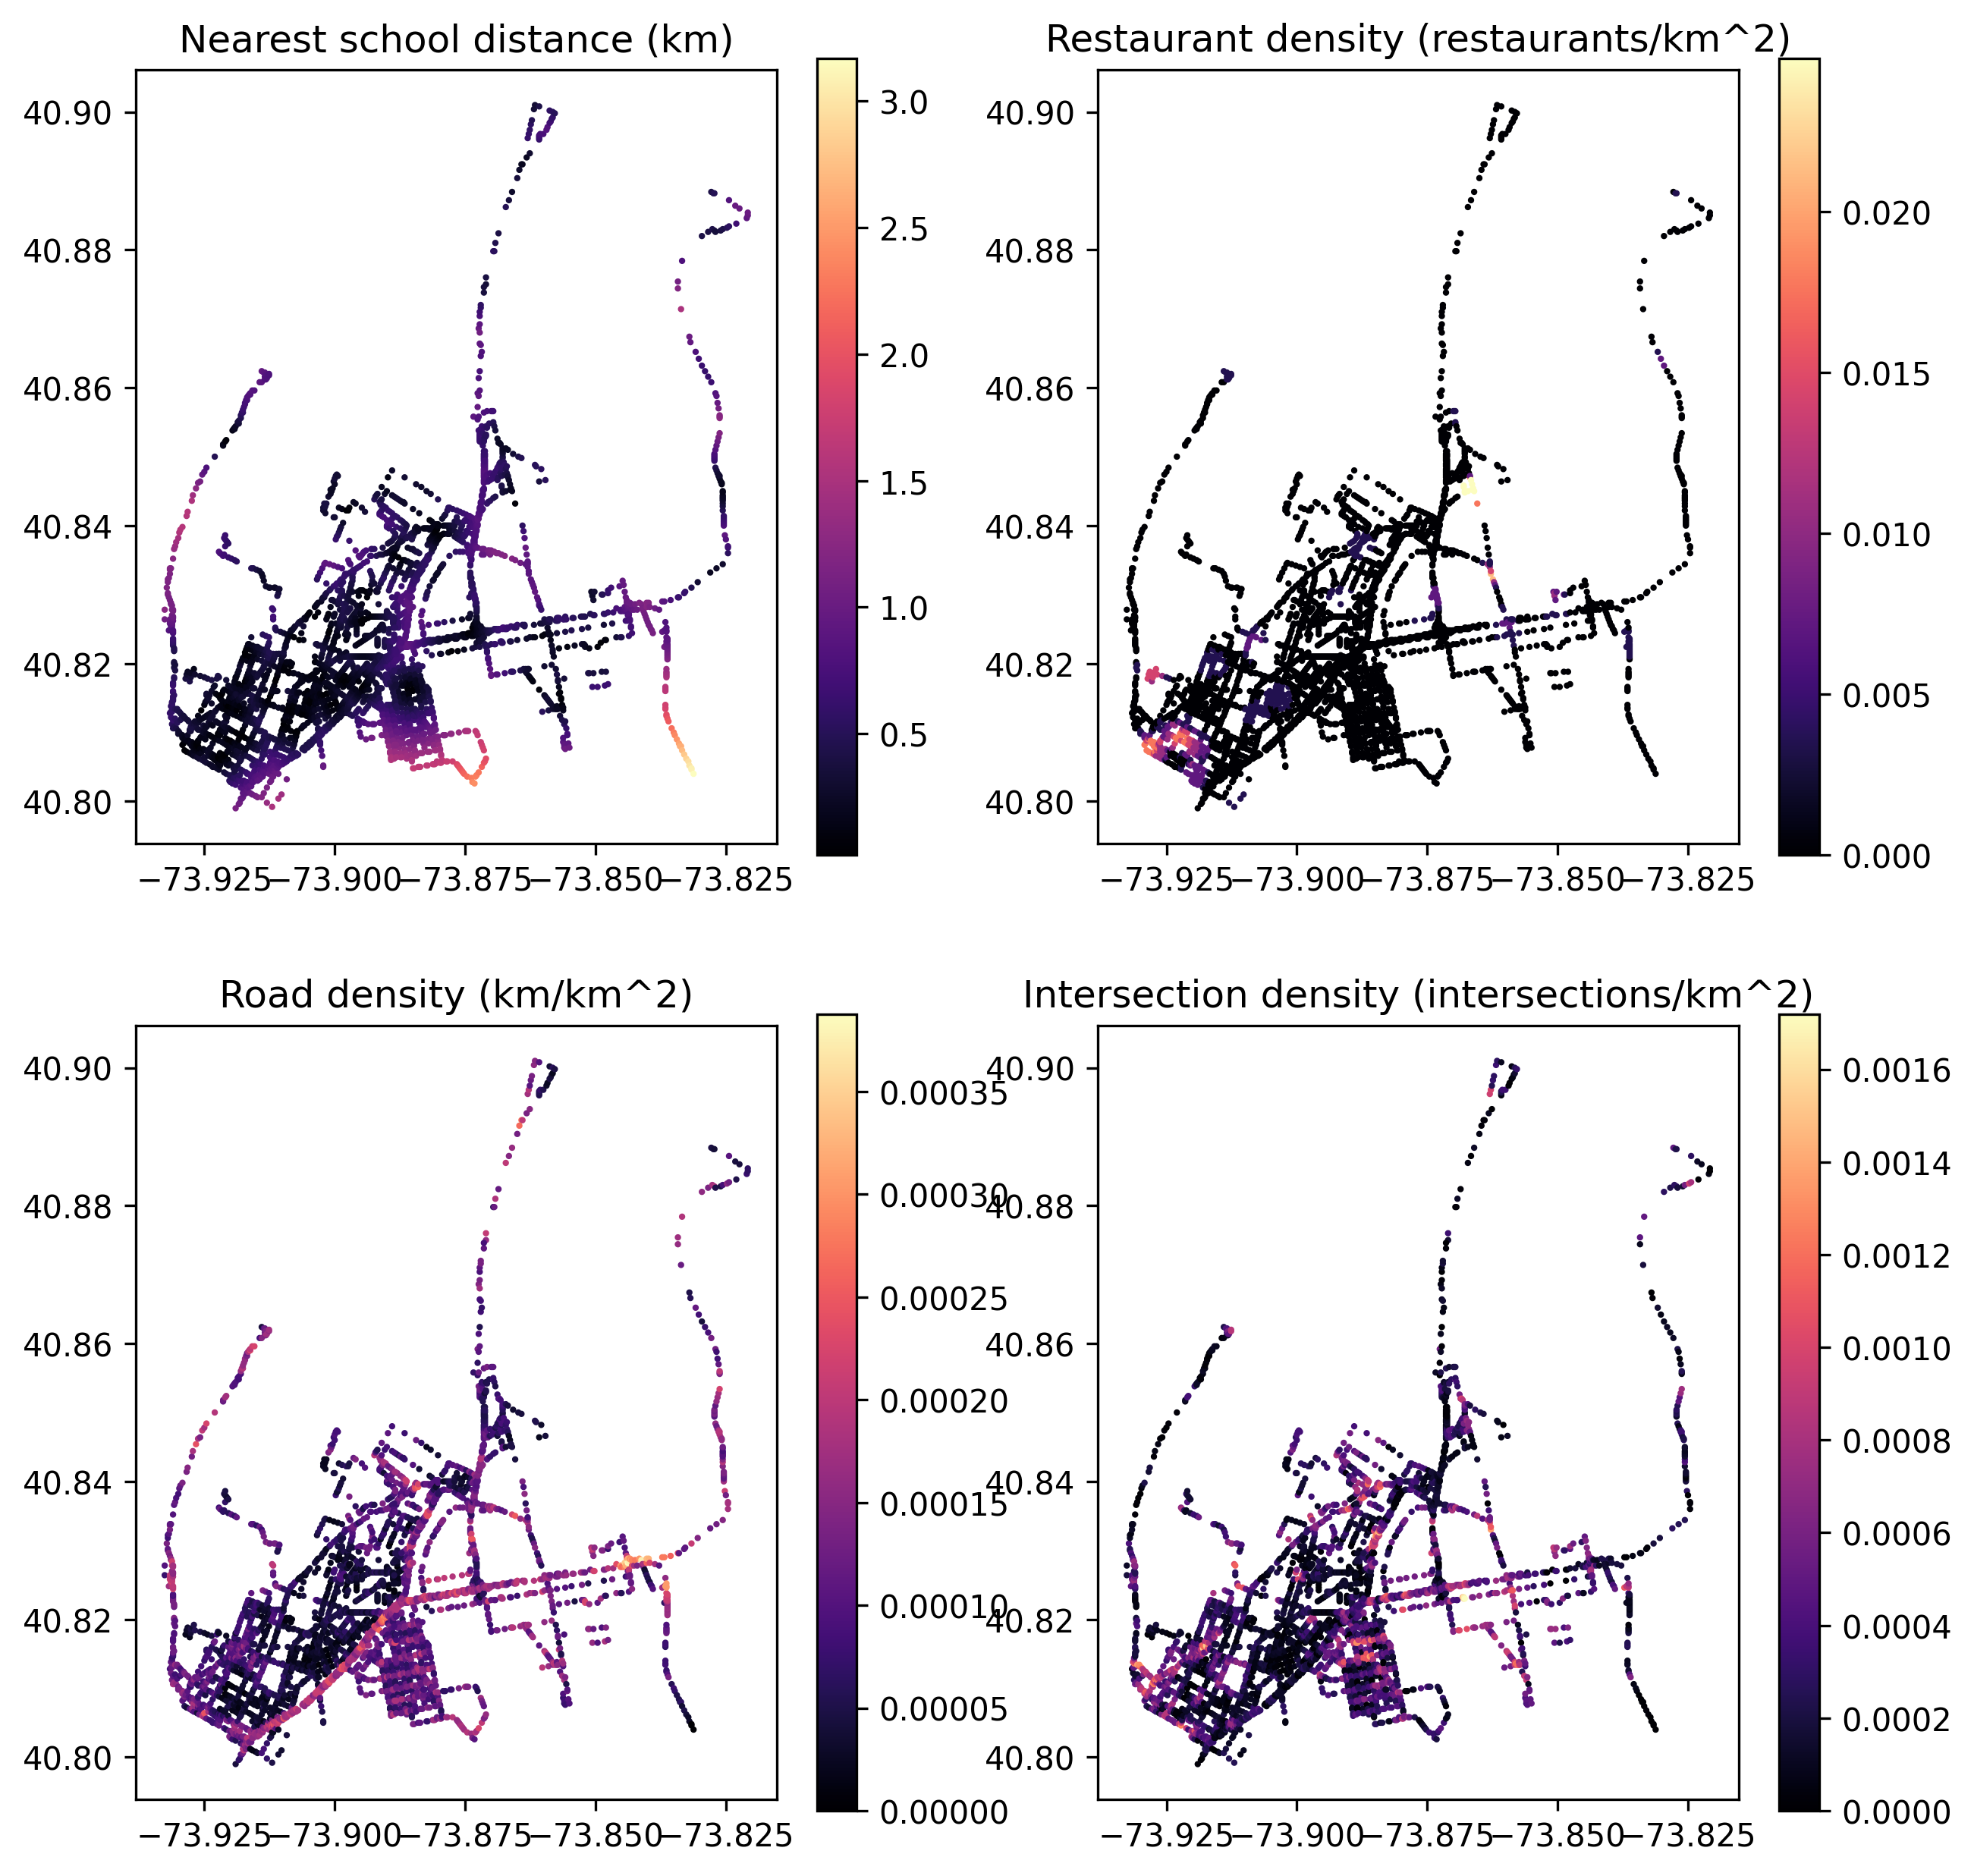

In [54]:
fig, ax = plt.subplots(2, 2, figsize=[10, 10])
pts.plot("nearest_school_distance", legend=True, ax=ax[0, 0], markersize=1, cmap="magma")
pts.plot("restaurant_density", legend=True, ax=ax[0, 1], markersize=1, cmap="magma")
pts.plot("road_density", legend=True, ax=ax[1, 0], markersize=1, cmap="magma")
pts.plot("intersection_density", legend=True, ax=ax[1, 1], markersize=1, cmap="magma")
ax[0, 0].set_title("Nearest school distance (km)")
ax[0, 1].set_title("Restaurant density (restaurants/km^2)")
ax[1, 0].set_title("Road density (km/km^2)")
ax[1, 1].set_title("Intersection density (intersections/km^2)")

# save the figure
fig.savefig(f"{root_dir}/notebooks/figs/point_features.png")

# save also every axis
for i, a in enumerate(ax.flat):
    a.get_figure().savefig(f"{root_dir}/notebooks/figs/point_features_{i}.png")

Extract labels (fine resolution PM2.5)

In [55]:
pts_feats = pts.copy()
y = pts_feats[["pm25", "geometry"]]
pts_feats = pts_feats.drop(columns=["road", "tract", "lon", "lat", "pm25"])

In [56]:
print("Final point features")
display(pts_feats)

Final point features


,time_of_day,geometry,restaurant_density,nearest_school_distance,road_density,intersection_density
8199,11.183333,POINT (-73.8882 40.8266),0.000000,0.558591,0.000050,0.000095
8201,13.200000,POINT (-73.8882 40.8288),0.000000,0.673612,0.000043,0.000223
8207,14.033333,POINT (-73.8882 40.833),0.000000,0.383996,0.000071,0.000191
8214,14.966667,POINT (-73.8882 40.8366),0.003537,0.172295,0.000074,0.000159
8218,14.766667,POINT (-73.8882 40.8398),0.000000,0.629355,0.000131,0.000828
...,...,...,...,...,...,...
8183,9.716667,POINT (-73.8882 40.8178),0.000000,0.386097,0.000071,0.000318
8186,12.183333,POINT (-73.8882 40.8204),0.000000,0.680238,0.000093,0.000382
8187,10.750000,POINT (-73.8882 40.8206),0.000000,0.706377,0.000102,0.000414
8189,15.650000,POINT (-73.8882 40.8214),0.000000,0.676090,0.000189,0.000446


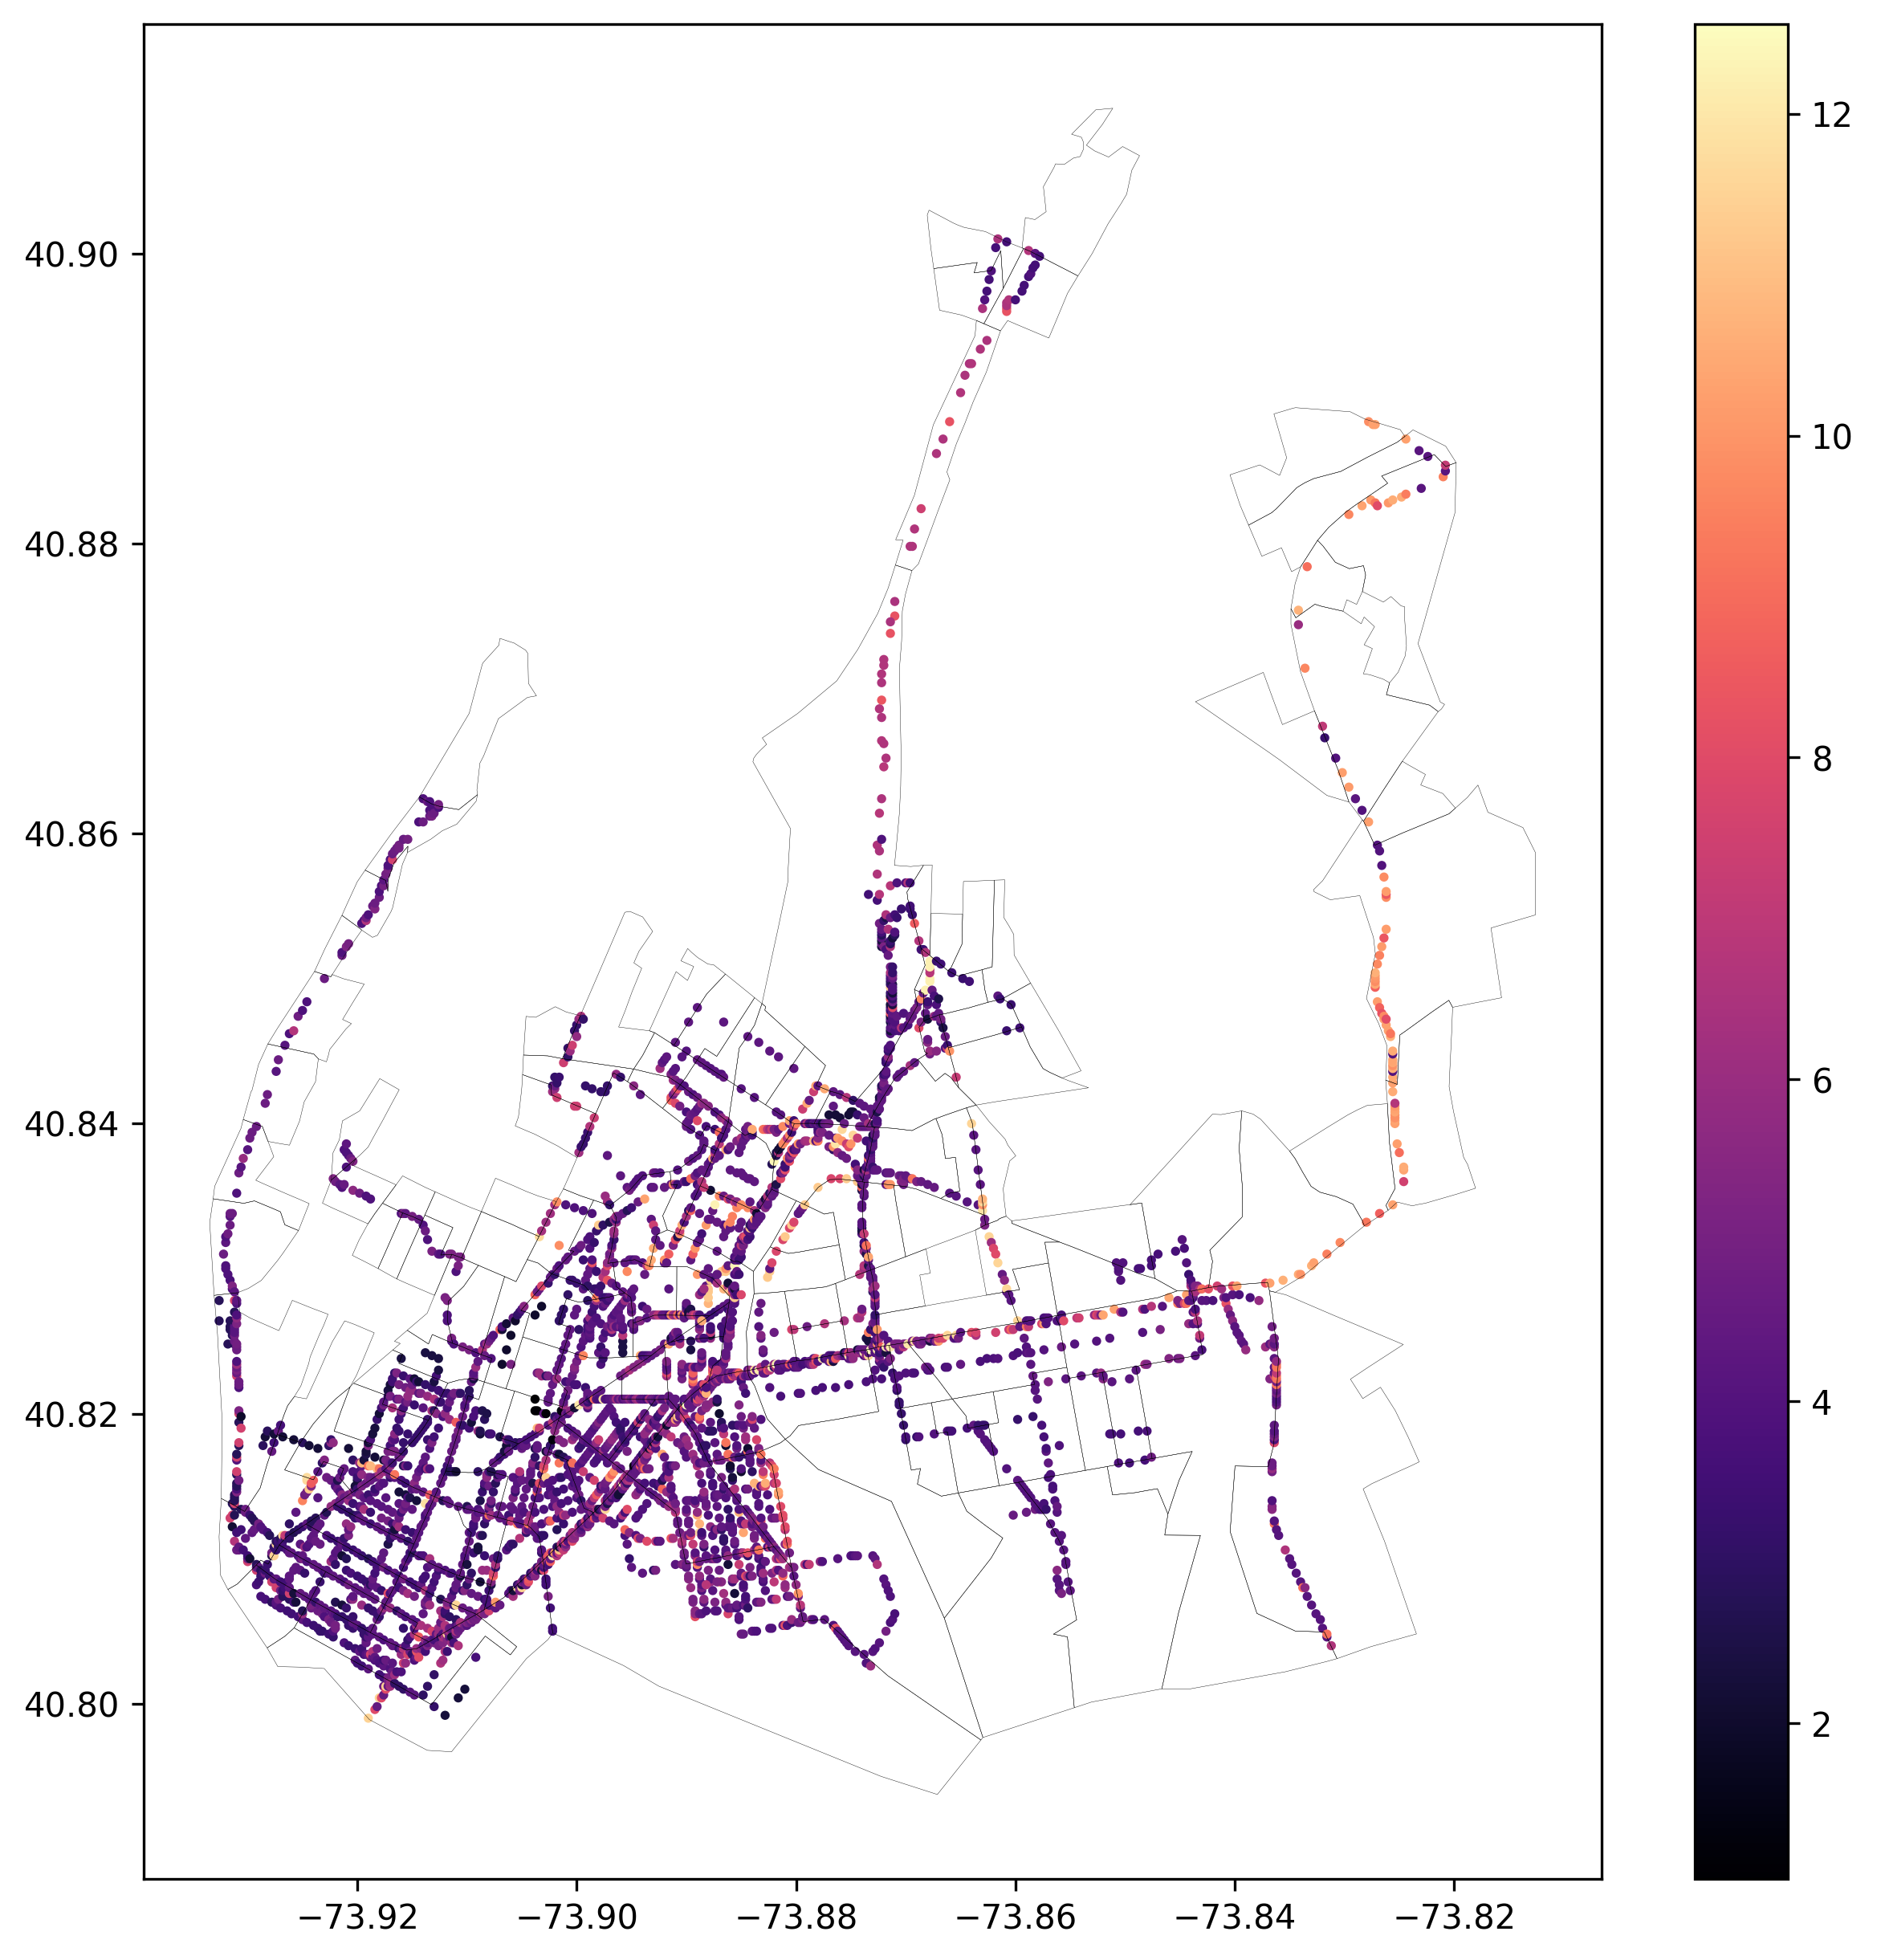

In [57]:
fig, ax = plt.subplots(figsize=[10, 10])
pts.plot("pm25", legend=True, markersize=3, cmap="magma", ax=ax)
tracts.boundary.plot(color="black", lw=0.1, ax=ax)
plt.savefig(f"{root_dir}/notebooks/figs/pm25_points.png")

### Road traffic-level (rank 1)

Obtain and visualize features from the AADT (Annual Average Daily Traffic) dataset.

In [58]:
# load aadt data, crs=2263, used in NYC commonly, convert to WGS84
aadt = gpd.read_file(f"{root_dir}/data/input/aadt_and_truckpct/features.shp", crs="EPSG:2263")
aadt = aadt.to_crs(wgs84)

# coerce the following vars to numeric, handling comma-separated numbers and % signs
print("Columns:", ", ".join(aadt.columns))
c = ["AADT_2021", "AAWDT_2021", "PCT_2021"]
for col in c:
    aadt[col] = pd.to_numeric(aadt[col].str.replace(",", "").str.replace("%", ""))

# crop to bounds of Bronx
aadt = aadt.cx[
    roads.total_bounds[0] : roads.total_bounds[2],
    roads.total_bounds[1] : roads.total_bounds[3],
]

/opt/homebrew/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


Columns: id, name, desc, county, route, fromMile, toMile, fc, latitude, longitude, AADT_2023, AAWDT_2023, PCT_2023, AADT_2022, AAWDT_2022, PCT_2022, AADT_2021, AAWDT_2021, PCT_2021, AADT_2020, AAWDT_2020, PCT_2020, AADT_2019, AAWDT_2019, PCT_2019, AADT_2018, AAWDT_2018, PCT_2018, AADT_2017, AAWDT_2017, PCT_2017, AADT_2016, AAWDT_2016, PCT_2016, geometry


Since we want the traffic at a road level. Use KNN regression to assign the traffic to the roads.

  0%|          | 0/550 [00:00<?, ?it/s]

Final road features


,AADT_2021,PCT_2021,geometry
1927,8140.926822,6.672728,"LINESTRING (-73.91676 40.81656, -73.91572 40.8..."
498,15745.868941,7.931295,"LINESTRING (-73.89139 40.82494, -73.89145 40.8..."
1587,5112.785193,6.609017,"LINESTRING (-73.90346 40.82853, -73.90283 40.8..."
1931,6263.247290,5.007908,"LINESTRING (-73.88998 40.82681, -73.88994 40.8..."
1255,14960.795698,7.785504,"LINESTRING (-73.90844 40.80648, -73.90821 40.8..."
...,...,...,...
2305,20235.031550,7.608175,"LINESTRING (-73.8893 40.82143, -73.88948 40.82..."
2662,6494.188165,9.668107,"LINESTRING (-73.88853 40.81871, -73.88888 40.82)"
0,30408.076005,7.617417,"LINESTRING (-73.88891 40.82181, -73.88858 40.8..."
904,8478.420547,9.296926,"LINESTRING (-73.88866 40.81776, -73.88739 40.8..."


Text(0.5, 1.0, 'Road AADT 2021 in Bronx, NY')

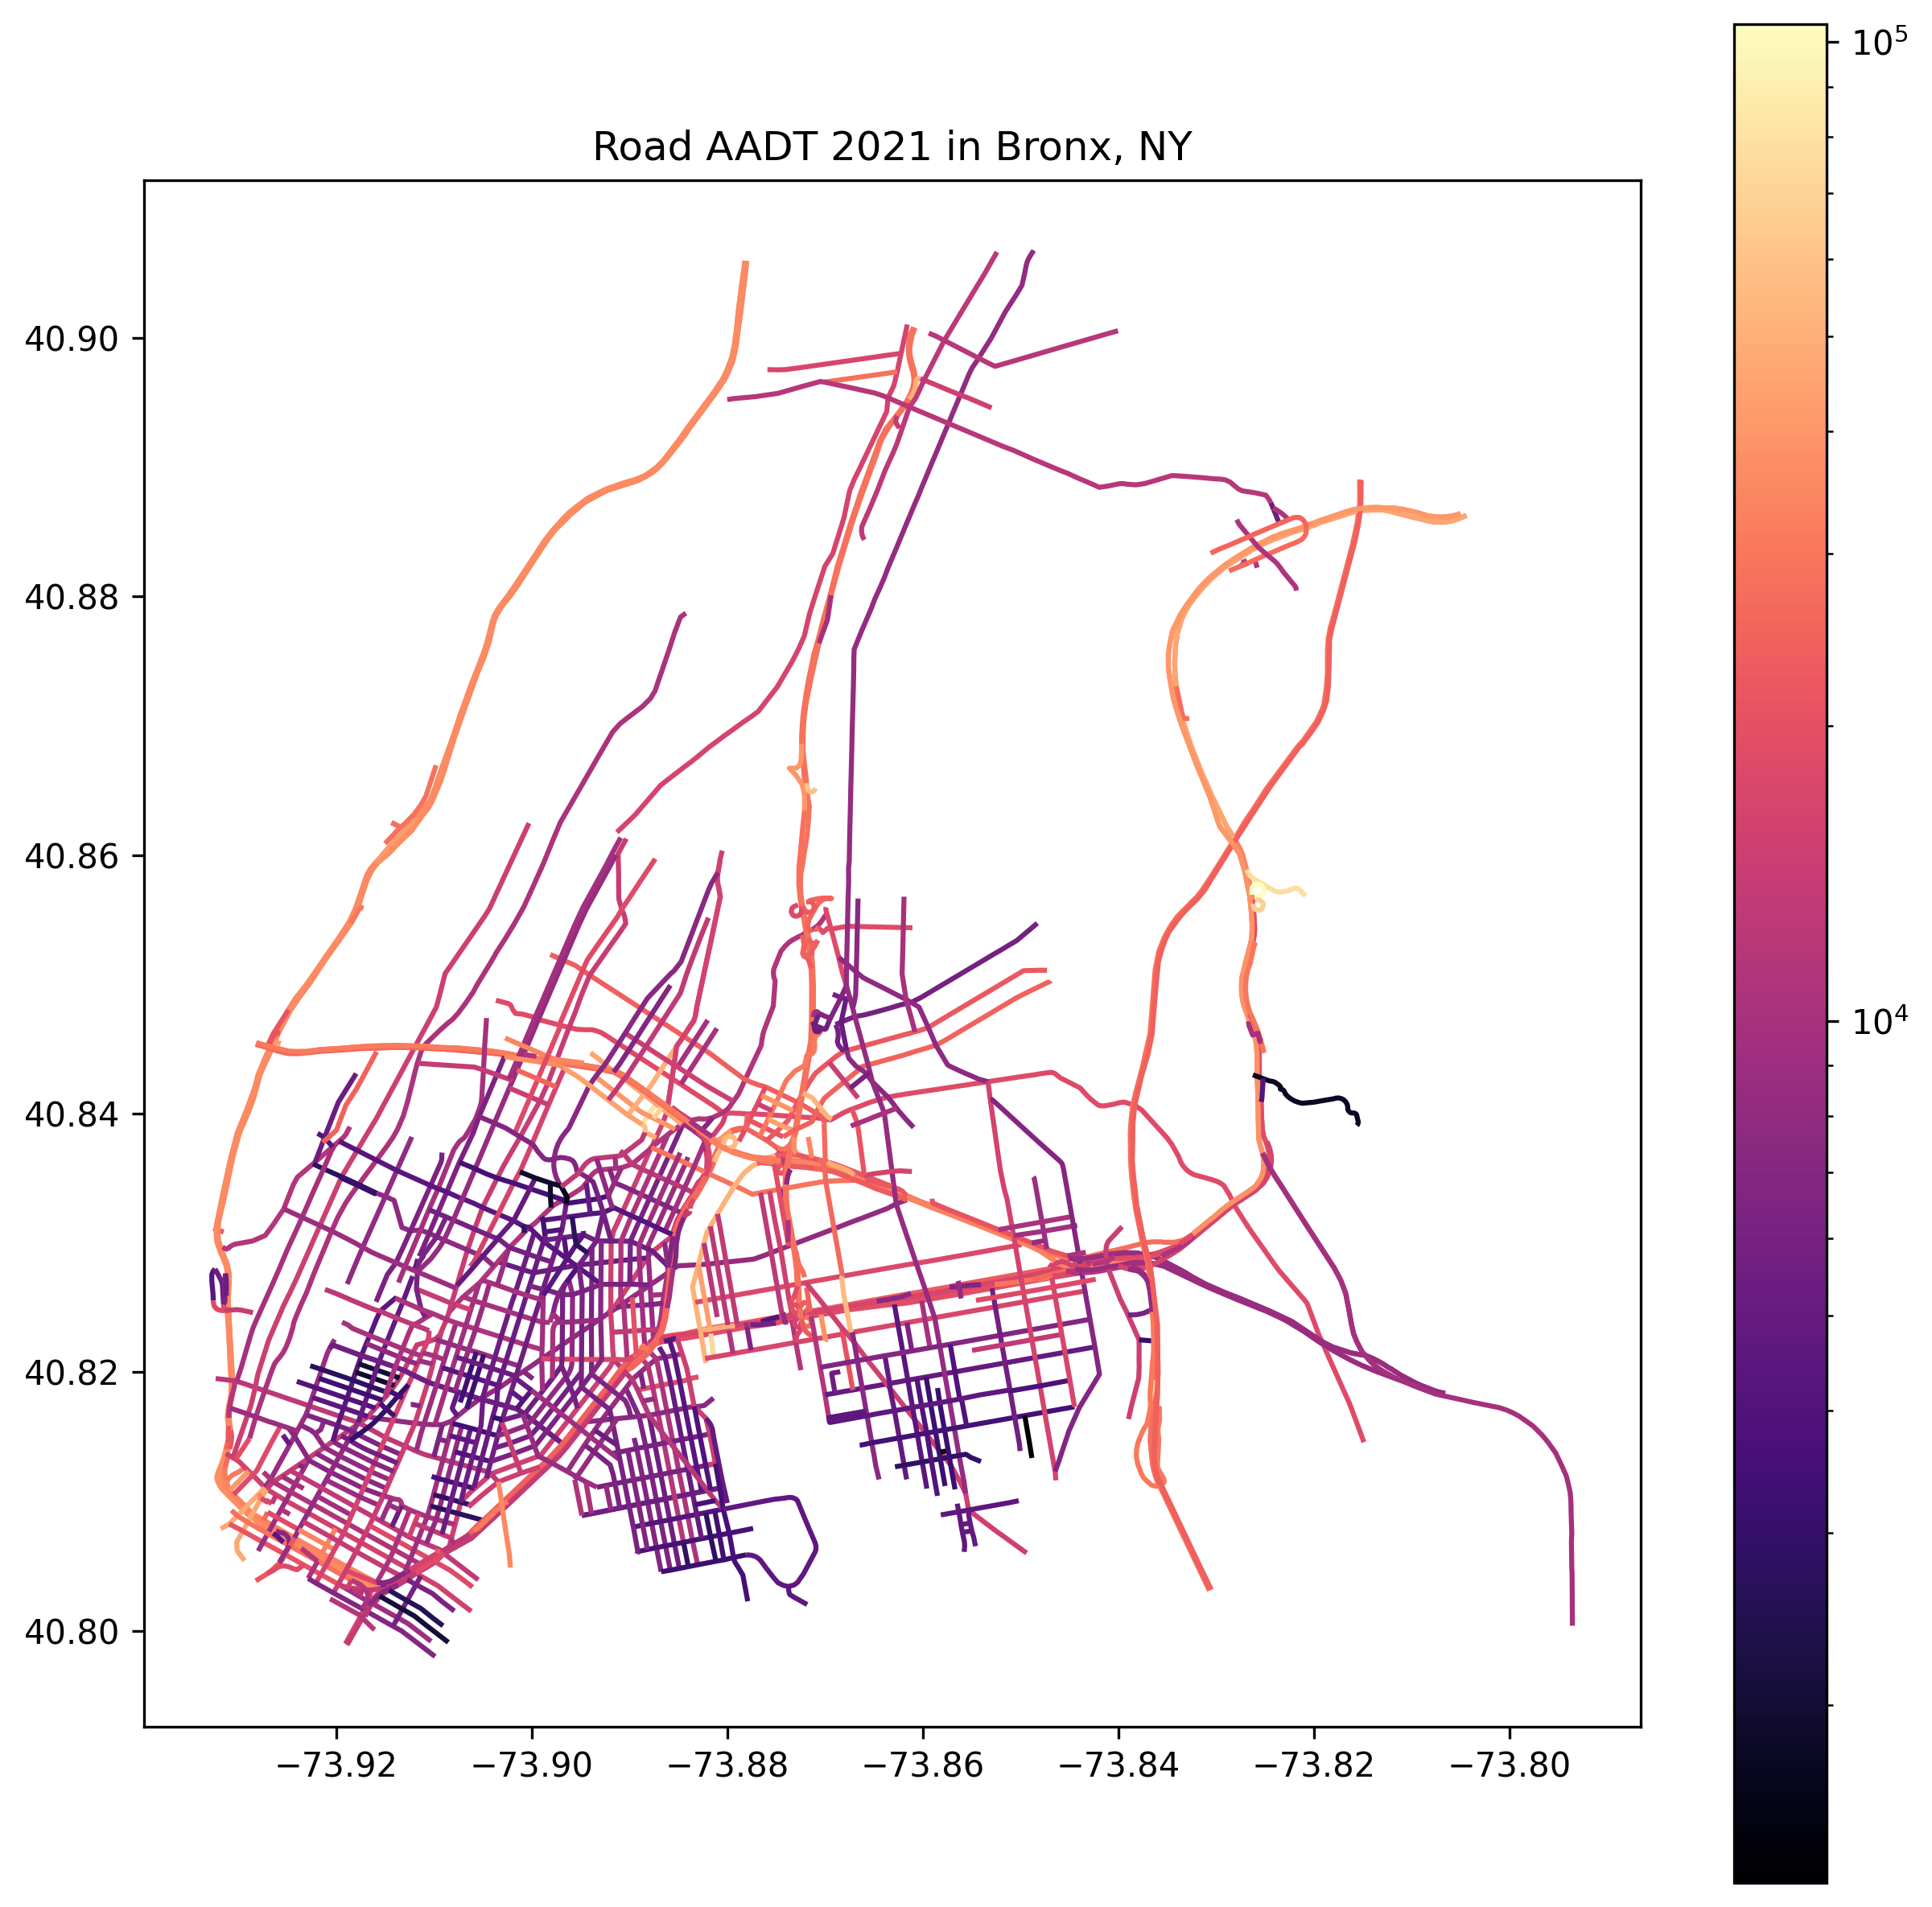

In [59]:
# make a weighted knn predictor
from sklearn.neighbors import KNeighborsRegressor

c = ["AADT_2021", "PCT_2021"]
Y = aadt[c]  # pandas
X = aadt[["longitude", "latitude"]]
knn = KNeighborsRegressor(n_neighbors=3, weights="distance")

# # remove NaNs
nan_ix = Y.isna().any(axis=1)
X = X.loc[~nan_ix]
Y = Y.loc[~nan_ix]

knn.fit(X, Y)

# predict AADT for each road, evaluate on all the points of the line and average
road_feats = []
for ix, row in tqdm(roads.iterrows(), total=roads.shape[0]):
    road = row.geometry
    lon, lat = road.xy
    Xtest = pd.DataFrame({"longitude": lon, "latitude": lat})
    preds = knn.predict(Xtest)
    road_feats.append(preds.mean(axis=0))
road_feats = np.array(road_feats)
road_feats = gpd.GeoDataFrame(
    road_feats, columns=Y.columns, geometry=roads.geometry.values, index=roads.index
)
print("Final road features")
display(road_feats)

norm = matplotlib.colors.LogNorm(
    vmin=road_feats.AADT_2021.min(), vmax=road_feats.AADT_2021.max()
)
fig, ax = plt.subplots(figsize=[10, 10])
road_feats.plot(column="AADT_2021", cmap="magma", norm=norm, legend=True, ax=ax)
# cx.add_basemap(ax, crs=roads.crs, source=cx.providers.USGS.USTopo)
plt.savefig(f"{root_dir}/notebooks/figs/road_feats.png")
plt.title("Road AADT 2021 in Bronx, NY")

### Census tracts from Coarse aggregated PM 2.5 & NYC zoning (rank 2)

We will now load the coarsen PM 2.5 dataset. The dataset is already in the repository under `data/tract_level_pm25.parquet`. These data is from Wei et al. (The Lancet Planetary Health; 2023). For convenience, we have pre-aggregated the values at the Census tract level from it's native 1km resolution (which is more lower than the 30m high-resolution targets here).

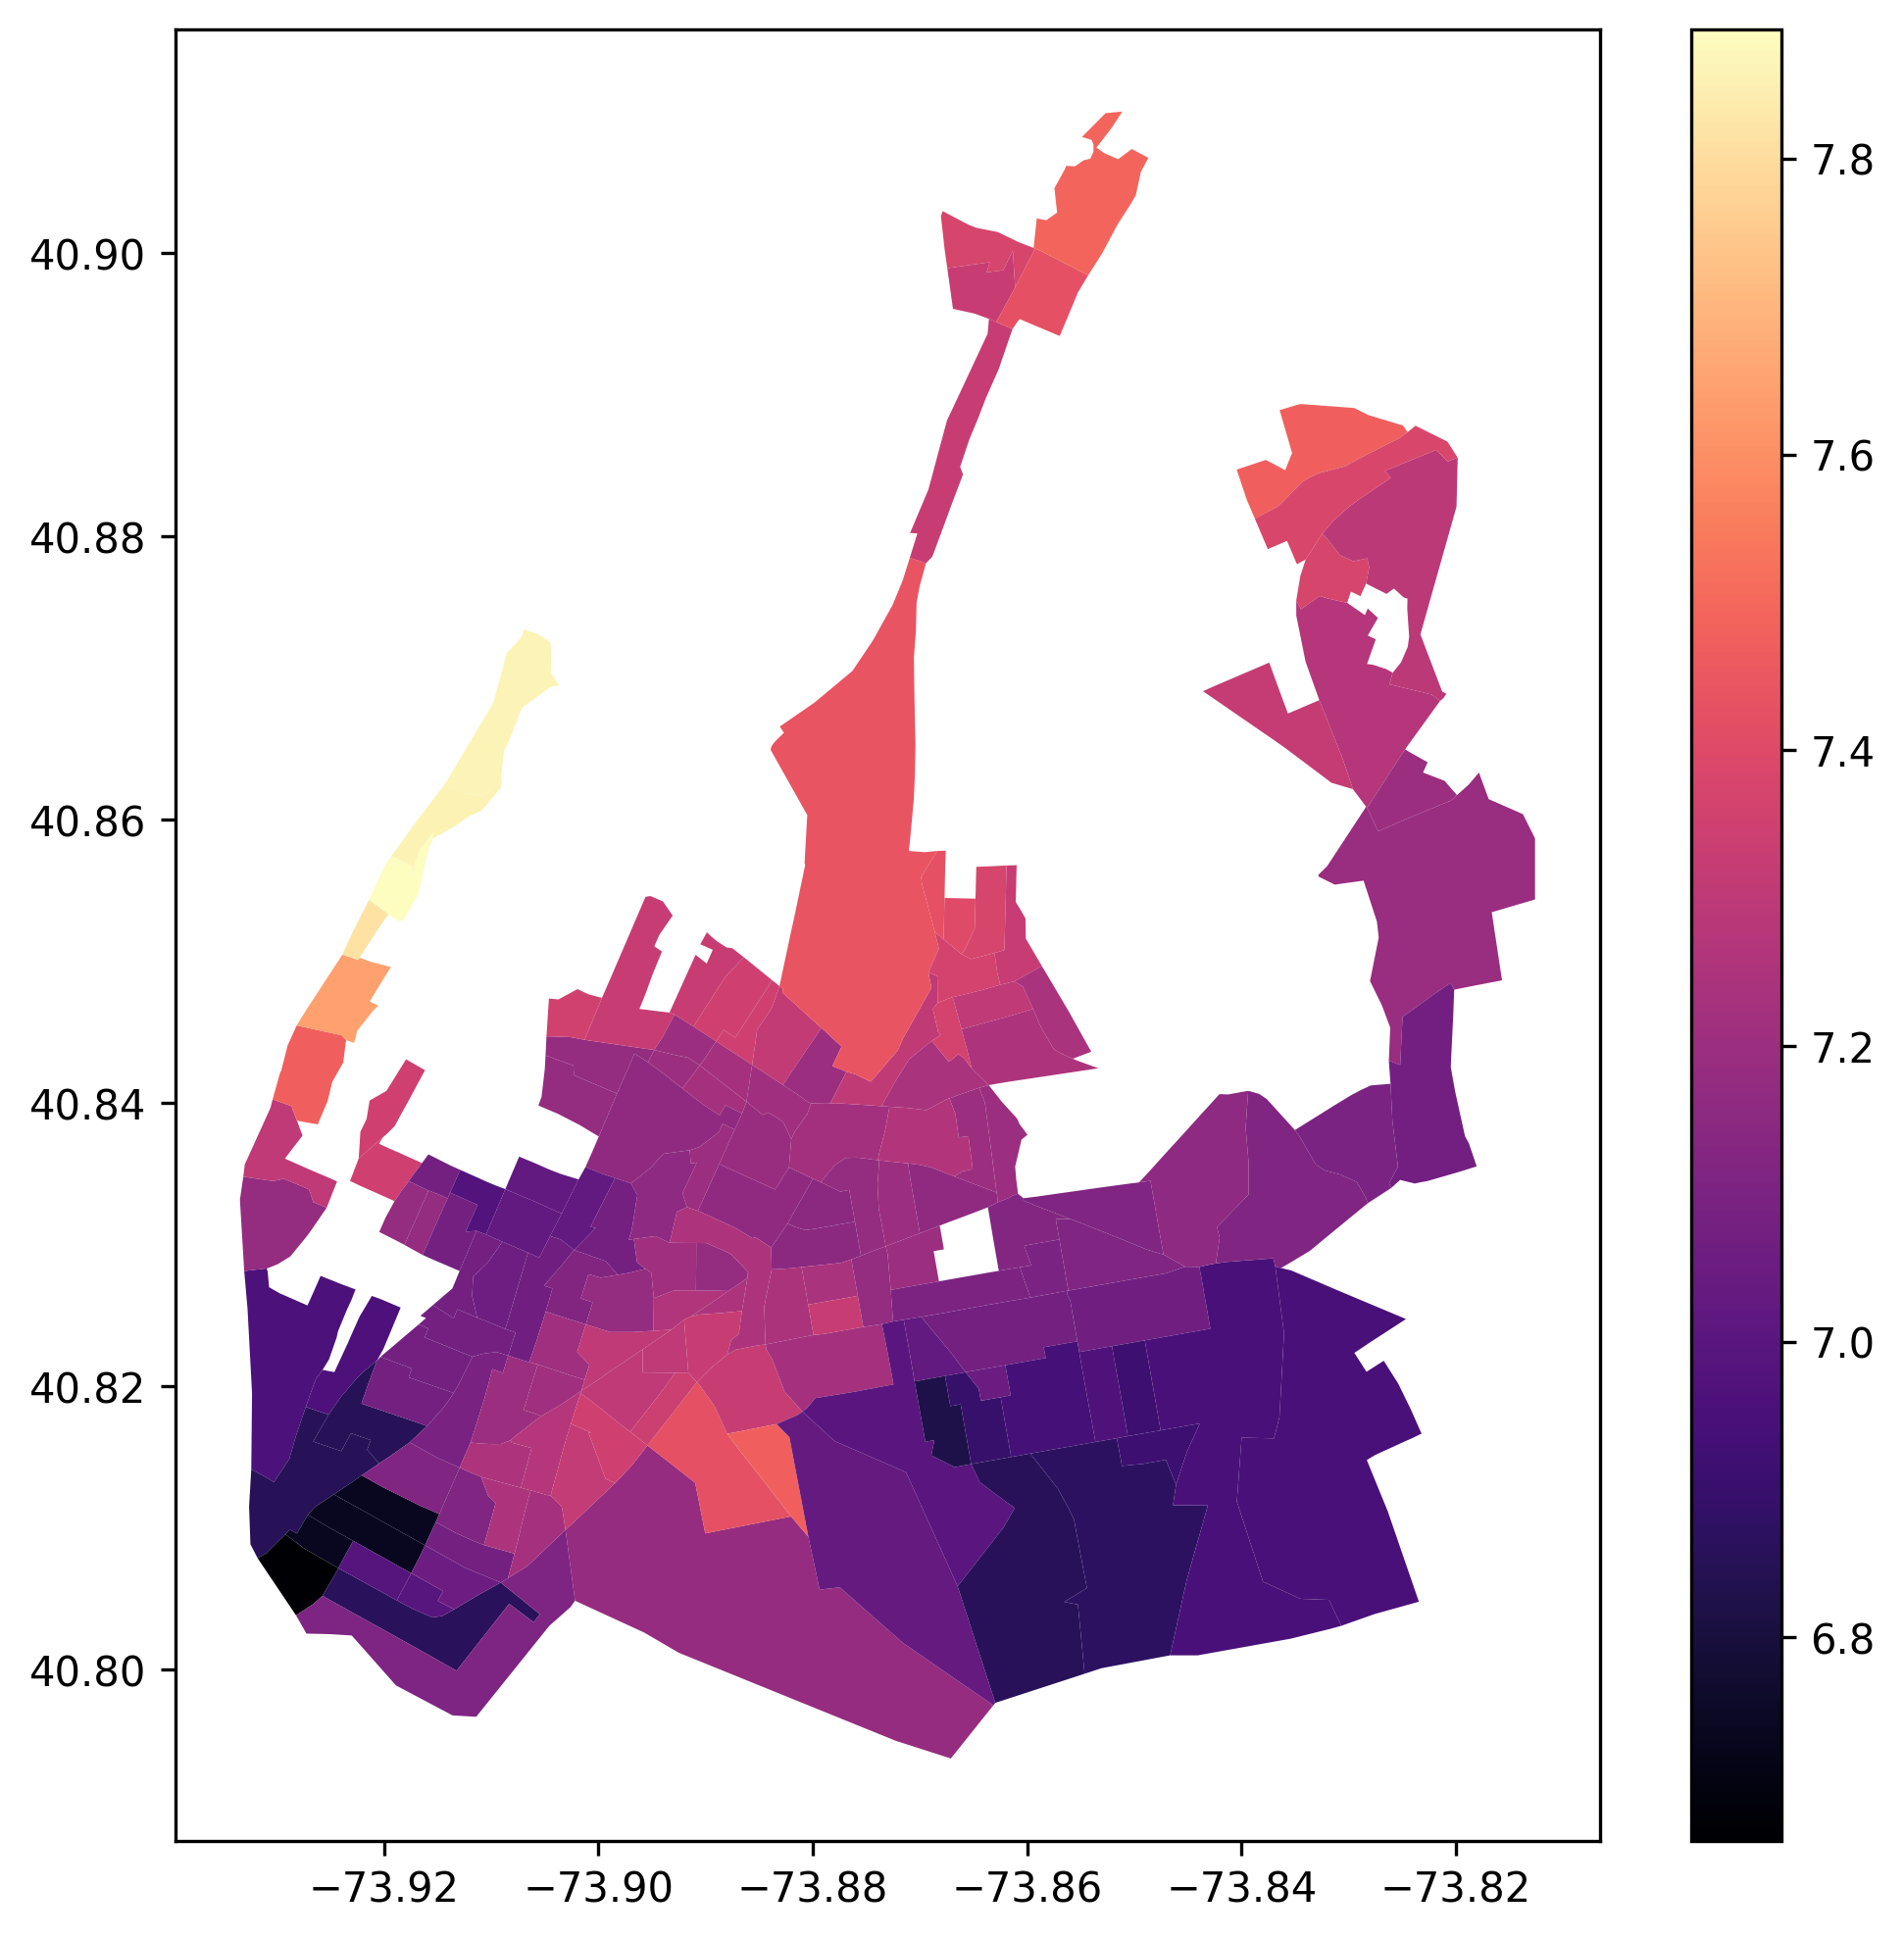

In [60]:
# cat pm25 to tracts
# these data already has only the months of the study period
monthly_tract_pm = pd.read_parquet(
    f"{root_dir}/data/input/coarse_pm25_bronx_tract_wei_et_al_2023.parquet"
)
monthly_tract_pm = monthly_tract_pm[monthly_tract_pm.month.isin([9, 10, 11, 12])]
tract_pm = (
    monthly_tract_pm.reset_index()
    .rename(columns={"bronx": "GEOID"})
    .groupby("GEOID")  # rename and aggregate by month at the same time
    .agg(coarse_pm25=pd.NamedAgg(column="PM2.5", aggfunc="mean"))
    .reset_index()
    .set_index("GEOID")
)

# left join on GEOID columns
tracts["coarse_pm25_predictor"] = tract_pm.coarse_pm25.loc[tracts.GEOID.values].values
# tracts = tracts.merge(tract_pm, how="left", on="GEOID
tracts.plot(column="coarse_pm25_predictor", legend=True, cmap="magma")

# visualize pm 25
os.makedirs(f"{root_dir}/notebooks/figs", exist_ok=True)
plt.savefig(f"{root_dir}/notebooks/figs/bronx_pm25.png")

We now add features from the PLUTO 

In [63]:
# Primary Land Use Tax Lot Output (PLUTO)
# crs=2263, used in NYC commonly, convert to WGS84
df = pd.read_csv(f"{root_dir}/data/input/nyc_pluto_25v1_1_csv/pluto_25v1_1.csv", low_memory=False)
df.rename(columns={"block": "tax_block"}, inplace=True)
df.rename(columns={"bctcb2020": "block"}, inplace=True)
df.rename(columns={"bct2020": "tract"}, inplace=True)
print("Columns:", ", ".join(df.columns))

# remove NaNs from bctcb2020zw
df = df[df.borough == "BX"]

# process as string and keep only last 4 digits
df = df[df.block.notna() & df.landuse.notna()]
df["block"] = df["block"].astype(int).astype(str).str[-4:].astype(int)
df["tract"] = df["tract"].astype(int).astype(str).str[-6:].astype(int)
display(df)

# transform assesstot to millions of dollar
df["assesstot"] = df["assesstot"] / 1e6

# categorical variables to be made one-hot and summed
# cat_cols = ["bldgclass", "landuse"]
cat_cols = ["landuse"]

area_feats = [
    "bldgarea",
    "comarea",
    "resarea",
    "officearea",
    "retailarea",
    "factryarea",
]

# map land use
mapping = [
    ([1], "one_two_family"),
    ([2, 3], "multi_family_elevator"),
    ([4, 5], "mixed_residential_commercial"),
    # ([5], "commercial_office"),
    ([6], "industrial_manufacturing"),
    ([7], "transportation_utility"),
    ([8], "public_facilities_institutions"),
    ([9], "open_space_outdoor_recreation"),
    ([10, 11], "parking/vacant"),
]
df["landuse"] = df["landuse"].astype(int)
for classes, new_class in mapping:
    df.loc[df.landuse.isin(classes), "landuse"] = new_class

# features to be averaged by LotArea
av_feats = ["assesstot", "lotfront", "lotdepth"]

orig_cols = df.columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, prefix=cat_cols)
new_cat_cols = list(df.columns.difference(orig_cols))
print("New dummy columns:", ", ".join(new_cat_cols))

# do groupby, start with sum
dfagg = df.groupby(["tract"])[area_feats + new_cat_cols + ["lotarea"]].sum()

# now compute an weighted average of av_feats by LotArea
def nan_weighted_mean(x, wts):
    isna = np.isnan(x) | np.isnan(wts)
    x = x[~isna]
    wts = wts[~isna] + 1e-6
    return np.nanmean(x * wts) / np.nansum(wts)


for col in av_feats + new_cat_cols:
    dfagg[col] = df.groupby("tract")[[col, "lotarea"]].apply(
        lambda x: nan_weighted_mean(x[col].values, x.lotarea.values)
    )


# transform the count and area features to density and pcts respectively by dividing by lotarea
for col in area_feats:
    dfagg[col] = dfagg[col] / dfagg["lotarea"]

# transform lot area from squared feed to squared kilometers
dfagg["lotarea"] = dfagg["lotarea"] * 0.000000092903

# remove nans
dfagg = dfagg.dropna()
print("Columns:", ", ".join(dfagg.columns))

# find the elements in dfagg.index that are also in tracts.TRACTCE
indexes = dfagg.index[dfagg.index.isin(tracts.index)]
dfagg = dfagg.loc[indexes]
tracts = tracts.loc[indexes]

# convert to gpd
tract_feats = gpd.GeoDataFrame(
    dfagg, geometry=tracts.geometry.loc[dfagg.index], crs=tracts.crs, index=dfagg.index
)
tract_feats["coarse_pm25"] = tracts.coarse_pm25_predictor.loc[
    tract_feats.index.values
].values
tract_feats = tract_feats.reset_index()
tract_feats = tract_feats.rename({"tract": "id"}, axis=1)

Columns: borough, tax_block, lot, cd, tract, block, ct2010, cb2010, schooldist, council, zipcode, firecomp, policeprct, healthcenterdistrict, healtharea, sanitboro, sanitdistrict, sanitsub, address, zonedist1, zonedist2, zonedist3, zonedist4, overlay1, overlay2, spdist1, spdist2, spdist3, ltdheight, splitzone, bldgclass, landuse, easements, ownertype, ownername, lotarea, bldgarea, comarea, resarea, officearea, retailarea, garagearea, strgearea, factryarea, otherarea, areasource, numbldgs, numfloors, unitsres, unitstotal, lotfront, lotdepth, bldgfront, bldgdepth, ext, proxcode, irrlotcode, lottype, bsmtcode, assessland, assesstot, exempttot, yearbuilt, yearalter1, yearalter2, histdist, landmark, builtfar, residfar, commfar, facilfar, borocode, bbl, condono, tract2010, xcoord, ycoord, zonemap, zmcode, sanborn, taxmap, edesignum, appbbl, appdate, plutomapid, firm07_flag, pfirm15_flag, version, dcpedited, latitude, longitude, notes


,borough,tax_block,lot,cd,tract,block,ct2010,cb2010,schooldist,council,...,appbbl,appdate,plutomapid,firm07_flag,pfirm15_flag,version,dcpedited,latitude,longitude,notes
6,BX,5933,149,208.0,30900,1,309.00,1.0,NaN,11.0,...,NaN,NaN,1,1.0,1.0,25v1.1,t,40.904463,-73.914268,NaN
81,BX,5486,114,210.0,16000,1,160.00,1.0,NaN,13.0,...,NaN,NaN,1,1.0,1.0,25v1.1,NaN,40.828309,-73.812768,NaN
84,BX,5654,235,228.0,50400,1015,504.00,1007.0,11.0,13.0,...,NaN,NaN,1,1.0,1.0,25v1.1,t,40.885804,-73.818526,NaN
95,BX,5256,133,210.0,46203,3001,462.01,1001.0,11.0,12.0,...,NaN,NaN,1,1.0,1.0,25v1.1,t,40.880533,-73.821433,NaN
98,BX,5409,139,210.0,27402,2,274.02,2.0,NaN,13.0,...,NaN,NaN,1,1.0,1.0,25v1.1,NaN,40.838525,-73.815937,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855371,BX,3384,81,212.0,45101,1003,451.01,1003.0,11.0,11.0,...,NaN,NaN,1,NaN,NaN,25v1.1,NaN,40.898171,-73.864257,NaN
855404,BX,5263,155,212.0,46209,1017,462.02,1016.0,11.0,12.0,...,NaN,NaN,1,NaN,NaN,25v1.1,t,40.880955,-73.832245,NaN
855982,BX,5643,625,210.0,51601,1,516.00,2.0,NaN,13.0,...,NaN,NaN,4,1.0,1.0,25v1.1,t,40.847503,-73.781340,NaN
858200,BX,5408,299,210.0,27401,3005,274.01,3014.0,8.0,13.0,...,NaN,NaN,1,NaN,NaN,25v1.1,NaN,40.839691,-73.822855,NaN


New dummy columns: landuse_mixed_residential_commercial, landuse_multi_family_elevator, landuse_one_two_family, landuse_open_space_outdoor_recreation, landuse_parking/vacant, landuse_public_facilities_institutions, landuse_transportation_utility
Columns: bldgarea, comarea, resarea, officearea, retailarea, factryarea, landuse_mixed_residential_commercial, landuse_multi_family_elevator, landuse_one_two_family, landuse_open_space_outdoor_recreation, landuse_parking/vacant, landuse_public_facilities_institutions, landuse_transportation_utility, lotarea, assesstot, lotfront, lotdepth


In [64]:
# final set of tract features
print("Final tract features")
display(tract_feats)

Final tract features


,id,bldgarea,comarea,resarea,officearea,retailarea,factryarea,landuse_mixed_residential_commercial,landuse_multi_family_elevator,landuse_one_two_family,landuse_open_space_outdoor_recreation,landuse_parking/vacant,landuse_public_facilities_institutions,landuse_transportation_utility,lotarea,assesstot,lotfront,lotdepth,geometry,coarse_pm25
0,200,0.266401,0.014688,0.230254,0.000223,0.004151,0.002596,0.000006,0.000048,0.000330,0.000009,0.000663,0.000015,0.000000,0.583213,0.000243,0.339117,0.434072,"POLYGON ((-73.86648 40.8059, -73.86222 40.8100...",6.85625
1,400,0.263811,0.014730,0.236161,0.000901,0.003073,0.000000,0.000011,0.000258,0.000240,0.000458,0.000255,0.000015,0.000002,0.849728,0.008426,0.410327,0.761597,"POLYGON ((-73.8587 40.8154, -73.85778 40.81553...",6.87000
2,1600,1.108538,0.441086,0.637455,0.081858,0.018111,0.000000,0.000287,0.000344,0.000455,0.000476,0.000361,0.000716,0.000000,0.333538,0.033256,0.885690,0.888166,"POLYGON ((-73.86246 40.81925, -73.86153 40.819...",6.93750
3,1901,3.830383,0.957967,2.867098,0.216681,0.230910,0.056723,0.006307,0.001481,0.000000,0.000000,0.001778,0.000550,0.000204,0.069696,0.198605,2.123340,2.481584,"POLYGON ((-73.93094 40.80825, -73.92933 40.809...",6.66250
4,1902,1.453588,1.006962,0.372166,0.081079,0.031895,0.540432,0.000348,0.000159,0.000164,0.000184,0.000183,0.000065,0.000541,0.226121,0.006637,0.469884,0.557185,"POLYGON ((-73.92446 40.80689, -73.92426 40.807...",6.86000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,46203,0.426080,0.334286,0.077940,0.067065,0.043229,0.005222,0.001818,0.000086,0.000173,0.000415,0.005515,0.001363,0.000326,0.343966,0.050427,4.984768,3.189251,"POLYGON ((-73.83245 40.88022, -73.83144 40.881...",7.29375
147,46205,0.659798,0.658383,0.000000,0.197960,0.245396,0.000000,0.014224,0.000000,0.000000,0.000230,0.002421,0.010903,0.000000,0.656787,1.888449,16.562153,15.162593,"POLYGON ((-73.83488 40.8755, -73.83444 40.8748...",7.27500
148,46207,1.902246,1.902246,0.000000,0.000000,0.848956,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.026264,27.638550,278.330000,676.000000,"POLYGON ((-73.8345 40.87723, -73.834 40.87839,...",7.37500
149,46209,0.655715,0.284988,0.348054,0.018468,0.050535,0.045397,0.000467,0.000976,0.000314,0.000000,0.000461,0.000155,0.000709,0.316625,0.011440,0.845501,0.961667,"POLYGON ((-73.83874 40.88127, -73.83664 40.882...",7.38500


Text(0.5, 1.0, 'Retailarea in Bronx, NY')

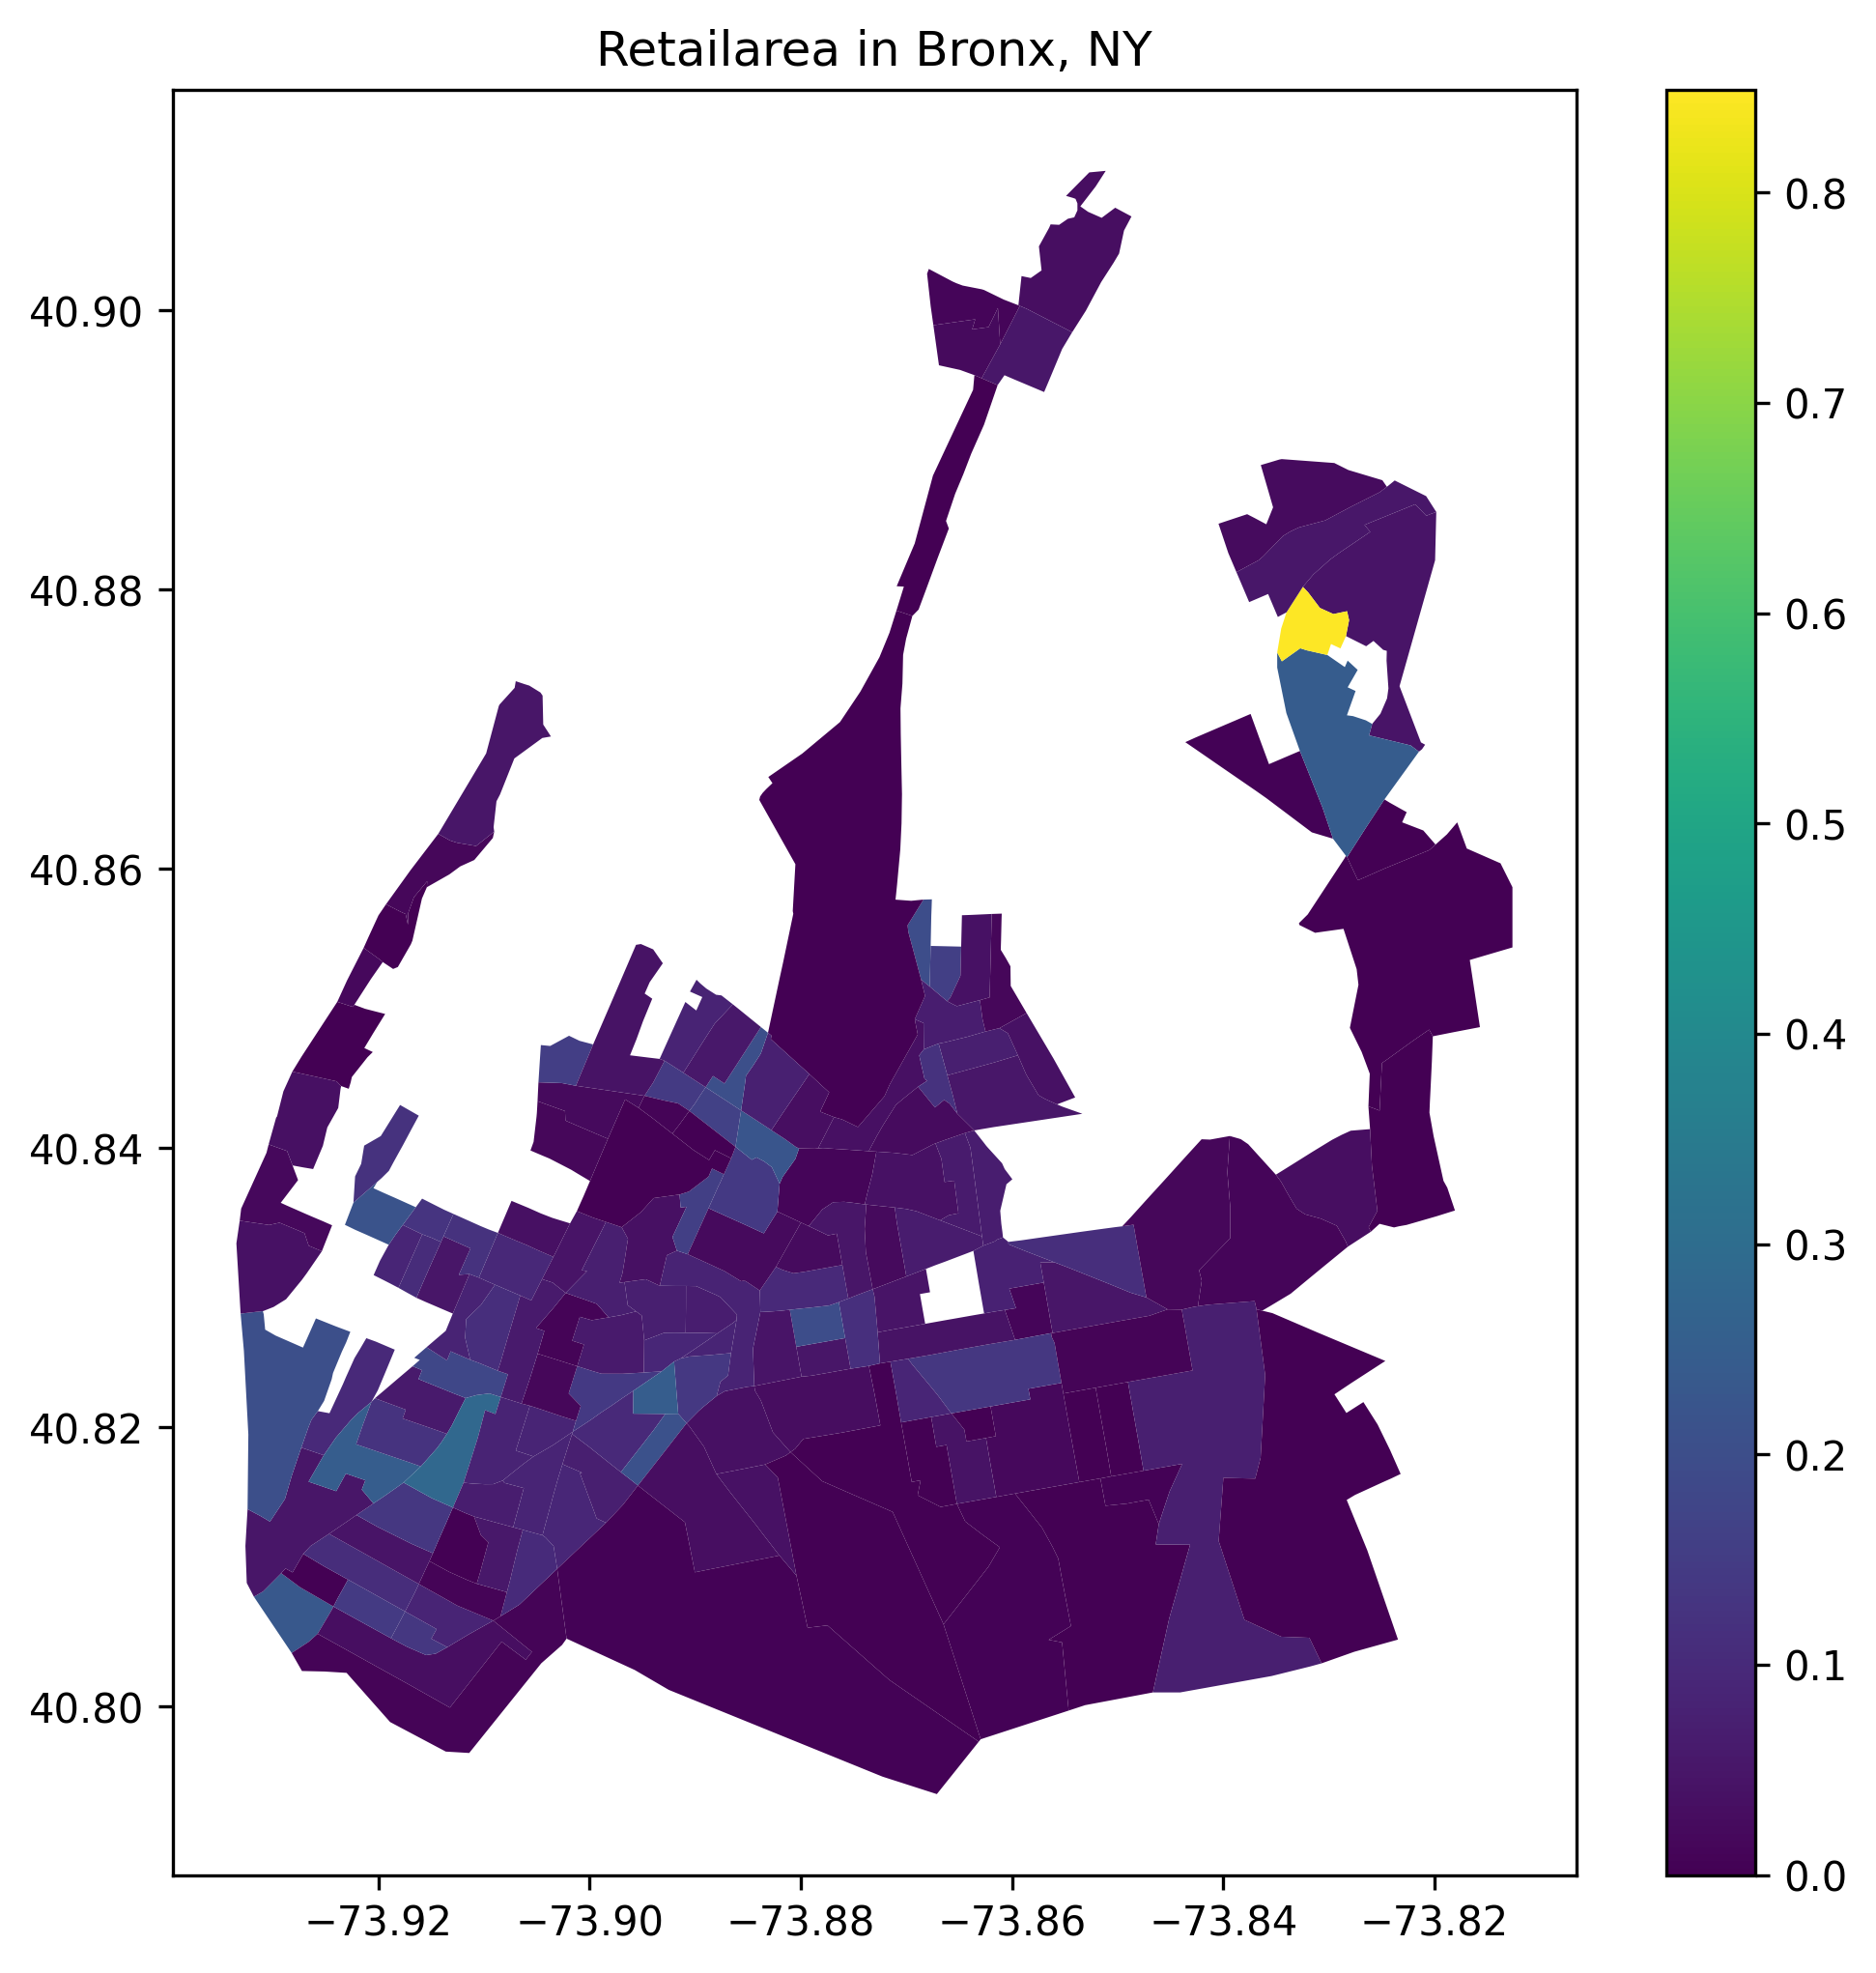

In [65]:
# visualize an exmple feature
tract_feats.plot("retailarea", legend=True)
plt.title("Retailarea in Bronx, NY")

## 4. Create adjacency graphs

#### Rank 0 Adjacency: KNN

In [66]:
# generate knn graph, record knn graph as list of edges
knn = NearestNeighbors(n_neighbors=3, metric="euclidean")
lon = pts_feats.geometry.x.values
lat = pts_feats.geometry.y.values
coords = np.stack([lon, lat], axis=1)
coords = pd.DataFrame(coords, columns=["lon", "lat"], index=pts.index)
knn.fit(coords)
distances, indices = knn.kneighbors(coords)
adj_pts = []
for ix, row in tqdm(enumerate(indices), total=indices.shape[0]):
    for i in row:
        if ix != i:
            adj_pts.append([int(ix), int(i)])

print("Number of points:", pts_feats.shape[0])
print("Number of edges of KNN(4) graph on points:", len(adj_pts))

  0%|          | 0/3939 [00:00<?, ?it/s]

Number of points: 3939
Number of edges of KNN(4) graph on points: 7878


#### Rank 1/2 Adjacency: Spatial Contiguity

In [67]:
sjoin = gpd.sjoin(roads_buff, roads_buff, predicate="intersects", how="inner")
adj_roads = []
for ix, row in tqdm(sjoin.iterrows(), total=sjoin.shape[0]):
    if ix != row.index_right:
        adj_roads.append([int(ix), int(row.index_right)])
print("Number of roads:", road_feats.shape[0])
print("Number of edges of adjacency graph on roads:", len(adj_roads))

  0%|          | 0/5306 [00:00<?, ?it/s]

Number of roads: 550
Number of edges of adjacency graph on roads: 4756


In [76]:
sjoin = gpd.sjoin(tract_buff, tract_buff, predicate="intersects", how="inner")
print("sjoin.columns:", sjoin.columns.tolist())
adj_tracts = []
for ix, row in tqdm(sjoin.iterrows(), total=sjoin.shape[0]):
    if ix != row["TRACTCE_right"]:
        adj_tracts.append([int(ix), int(row["TRACTCE_right"])])
print("Number of tracts:", tract_feats.shape[0])
print("Number of edges of adjacency graph on tracts:", len(adj_tracts))

sjoin.columns: ['geometry', 'TRACTCE_right']


  0%|          | 0/923 [00:00<?, ?it/s]

Number of tracts: 151
Number of edges of adjacency graph on tracts: 772


## 5. Export

In [78]:
adj_1_0 = np.zeros((2, len(edges_pts_road)), dtype=int)
adj_2_1 = np.zeros((2, len(edges_road_tract)), dtype=int)
adj_0_0 = np.zeros((2, len(adj_pts)), dtype=int)
adj_1_1 = np.zeros((2, len(adj_roads)), dtype=int)
adj_2_2 = np.zeros((2, len(adj_tracts)), dtype=int)

for j in range(adj_0_0.shape[1]):
    adj_0_0[0, j] = adj_pts[j][0]
    adj_0_0[1, j] = adj_pts[j][1]

for j in range(adj_1_1.shape[1]):
    adj_1_1[0, j] = ixmap_roads[adj_roads[j][0]]
    adj_1_1[1, j] = ixmap_roads[adj_roads[j][1]]

for j in range(adj_2_2.shape[1]):
    adj_2_2[0, j] = ixmap_tracts[adj_tracts[j][0]]
    adj_2_2[1, j] = ixmap_tracts[adj_tracts[j][1]]

for j in range(adj_1_0.shape[1]):
    adj_1_0[1, j] = edges_pts_road[j][0]
    adj_1_0[0, j] = edges_pts_road[j][1]

for j in range(adj_2_1.shape[1]):
    adj_2_1[1, j] = edges_road_tract[j][0]
    adj_2_1[0, j] = edges_road_tract[j][1]


data = {
    "x_0": pts_feats.drop(columns=["geometry"]).values.tolist(),
    "x_1": road_feats.drop(columns=["geometry"]).values.tolist(),
    "x_2": tract_feats.drop(columns=["geometry"]).values.tolist(),
    "pos": pts_feats.geometry.apply(lambda x: [x.x, x.y]).values.tolist(),
    "cell_0": cell_0,
    "cell_1": cell_1,
    "cell_2": cell_2,
    "adj_1_0": adj_1_0.tolist(),
    "adj_2_1": adj_2_1.tolist(),
    "adj_0_0": adj_0_0.tolist(),
    "adj_1_1": adj_1_1.tolist(),
    "adj_2_2": adj_2_2.tolist(),
    "adj_0_1": adj_1_0[::-1].tolist(),  # [::-1] flips the array
    "adj_1_2": adj_2_1[::-1].tolist(),
    "y": y[["pm25"]].values.tolist(),
    "points_to_cells": pts[["road", "tract"]].to_dict(),
}

data["num_features_dict"] = {
    0: len(data["x_0"][0]),
    1: len(data["x_1"][0]),
    2: len(data["x_2"][0]),
}


with open(f"{root_dir}/data/input/geospatialcc.json", "w") as f:
    json.dump(data, f)

In [80]:
# save pts vmap
pts[["road", "tract"]].to_csv(f"{root_dir}/data/spatial_cc/raw/point_to_cell.csv", index=False)